# Laboratorio 03 — Análisis exploratorio de una cohorte con diabetes tipo 2

**Autor:** Alejandro García Colorado  
**Fuente:** población sintética generada con Synthea 4.0.0  
**Cohorte de origen:** 23,006 pacientes  
**Fecha de corte:** 22 de agosto de 2026

## Objetivo

Realizar un análisis exploratorio de una cohorte de pacientes con diabetes
mellitus tipo 2 y presentar sus características demográficas, evolución de
un analito clínico y comorbilidades frecuentes mediante tablas y figuras
interpretables para un público clínico.

In [1]:
#Importaciones de paqueterías necesarias
from pathlib import Path
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly
import plotly.express as px
import seaborn as sns

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")
print(f"Plotly: {plotly.__version__}")

Python: 3.12.14
pandas: 2.3.3
Matplotlib: 3.11.1
Seaborn: 0.13.2
Plotly: 6.9.0


In [2]:
#Definimos las rutas de trabajo
PROJECT_ROOT = Path.cwd().parents[1]

DATA_DIR = PROJECT_ROOT / "lab02" / "data" / "synthea_20000" / "csv"
FIGURES_DIR = Path.cwd() / "figuras"
RESULTS_DIR = Path.cwd() / "resultados"

PATIENTS_FILE = DATA_DIR / "patients.csv"
ENCOUNTERS_FILE = DATA_DIR / "encounters.csv"
OBSERVATIONS_FILE = DATA_DIR / "observations.csv"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

for archivo in [PATIENTS_FILE, ENCOUNTERS_FILE, OBSERVATIONS_FILE]:
    print(f"{archivo.name}: existe = {archivo.exists()}")

patients.csv: existe = True
encounters.csv: existe = True
observations.csv: existe = True


In [3]:
#Identificamos los encuentros de personas con diabetes
CODIGOS_DIABETES_T2 = {
    "44054006",
    "368581000119106",
}

bloques_diabetes = []

for bloque in pd.read_csv(
    ENCOUNTERS_FILE,
    usecols=[
        "Id",
        "START",
        "PATIENT",
        "REASONCODE",
        "REASONDESCRIPTION",
    ],
    dtype={
        "Id": "string",
        "PATIENT": "string",
        "REASONCODE": "string",
        "REASONDESCRIPTION": "string",
    },
    chunksize=100_000,
):
    mascara = bloque["REASONCODE"].isin(CODIGOS_DIABETES_T2)
    bloques_diabetes.append(bloque.loc[mascara].copy())

encuentros_diabetes = pd.concat(
    bloques_diabetes,
    ignore_index=True,
)

encuentros_diabetes["START"] = pd.to_datetime(
    encuentros_diabetes["START"],
    errors="coerce",
    utc=True,
)

print(f"Encuentros seleccionados: {len(encuentros_diabetes):,}")
print(
    "Pacientes únicos:",
    f"{encuentros_diabetes['PATIENT'].nunique():,}",
)

encuentros_diabetes.head()

Encuentros seleccionados: 501
Pacientes únicos: 500


,Id,START,PATIENT,REASONCODE,REASONDESCRIPTION
0,8d3ebc60-a184-ee6f-b634-214288b38a7c,2022-05-22 12:39:23+00:00,8d3ebc60-a184-ee6f-4366-e81e0f7ba3bd,44054006,Diabetes mellitus type 2 (disorder)
1,670a051e-41fc-1de2-3114-22dd44ce8d99,2022-08-31 05:20:55+00:00,670a051e-41fc-1de2-0c1b-5fee053917cf,44054006,Diabetes mellitus type 2 (disorder)
2,92bc60bc-27d4-02b8-fce6-d07e9e87f965,2022-04-27 14:42:12+00:00,92bc60bc-27d4-02b8-c300-01eaa8331e4b,44054006,Diabetes mellitus type 2 (disorder)
3,d0b842ef-db53-b29e-0203-017fdfedc260,2023-11-11 21:41:34+00:00,d0b842ef-db53-b29e-6677-ccd563c9d5af,44054006,Diabetes mellitus type 2 (disorder)
4,5eb8d3ea-d9c9-a204-87d8-0d117cc7d40b,2025-07-07 01:04:29+00:00,5eb8d3ea-d9c9-a204-8535-b1b343781e92,44054006,Diabetes mellitus type 2 (disorder)


In [4]:
#Construir la lista de pacientes
pacientes_diabetes_ids = (
    encuentros_diabetes[["PATIENT"]]
    .drop_duplicates()
    .rename(columns={"PATIENT": "Id"})
    .reset_index(drop=True)
)

assert pacientes_diabetes_ids["Id"].is_unique
assert len(pacientes_diabetes_ids) == 500

pacientes_diabetes_ids.head()

,Id
0,8d3ebc60-a184-ee6f-4366-e81e0f7ba3bd
1,670a051e-41fc-1de2-0c1b-5fee053917cf
2,92bc60bc-27d4-02b8-c300-01eaa8331e4b
3,d0b842ef-db53-b29e-6677-ccd563c9d5af
4,5eb8d3ea-d9c9-a204-8535-b1b343781e92


In [5]:
#Cargamos los pacientes y construimos la cohorte final
pacientes = pd.read_csv(
    PATIENTS_FILE,
    dtype={
        "Id": "string",
        "SSN": "string",
        "DRIVERS": "string",
        "PASSPORT": "string",
        "PREFIX": "string",
        "FIRST": "string",
        "LAST": "string",
        "SUFFIX": "string",
        "MAIDEN": "string",
        "MARITAL": "category",
        "RACE": "category",
        "ETHNICITY": "category",
        "GENDER": "category",
        "BIRTHPLACE": "string",
        "ADDRESS": "string",
        "CITY": "string",
        "STATE": "category",
        "COUNTY": "category",
        "FIPS": "string",
        "ZIP": "string",
        "LAT": "float32",
        "LON": "float32",
        "HEALTHCARE_EXPENSES": "float32",
        "HEALTHCARE_COVERAGE": "float32",
        "INCOME": "Int32",
    },
)

pacientes["BIRTHDATE"] = pd.to_datetime(
    pacientes["BIRTHDATE"],
    errors="coerce",
)

pacientes["DEATHDATE"] = pd.to_datetime(
    pacientes["DEATHDATE"],
    errors="coerce",
)

cohorte = pacientes_diabetes_ids.merge(
    pacientes,
    on="Id",
    how="left",
    validate="one_to_one",
    indicator=True,
)

print(cohorte["_merge"].value_counts())

_merge
both          500
left_only       0
right_only      0
Name: count, dtype: int64


In [6]:
#Validamos la cohorte
assert len(cohorte) == 500
assert cohorte["Id"].is_unique
assert cohorte["_merge"].eq("both").all()

cohorte = cohorte.drop(columns="_merge")

print(f"Tamaño final de la cohorte: {len(cohorte):,}")
print(f"Identificadores únicos: {cohorte['Id'].nunique():,}")
print(f"Fecha de nacimiento faltante: {cohorte['BIRTHDATE'].isna().sum():,}")
print(f"Sexo faltante: {cohorte['GENDER'].isna().sum():,}")

Tamaño final de la cohorte: 500
Identificadores únicos: 500
Fecha de nacimiento faltante: 0
Sexo faltante: 0


## 2. Ejecutar el checklist completo de EDA sobre esa cohorte
## 3. Generar y comentar: distribución de edad por sexo, evolución temporal de un analito, comorbilidades más frecuentes

### Fecha índice y edad basal
Para cada paciente se definió como fecha índice el primer encuentro registrado
cuyo motivo correspondiera a diabetes mellitus tipo 2 o neuropatía debida a
diabetes tipo 2.

La edad basal se calculó entre la fecha de nacimiento y la fecha índice. Esta
decisión evita utilizar la edad al final de la simulación, que podría incorporar
diferentes tiempos de seguimiento entre pacientes.

In [7]:
#Obtenemos la fecha índice
fecha_indice = (
    encuentros_diabetes
    .groupby("PATIENT", as_index=False)
    .agg(fecha_indice=("START", "min"))
    .rename(columns={"PATIENT": "Id"})
)

# Retirar la zona horaria para poder compararla con BIRTHDATE
fecha_indice["fecha_indice"] = (
    fecha_indice["fecha_indice"]
    .dt.tz_convert(None)
)

assert fecha_indice["Id"].is_unique
assert len(fecha_indice) == 500

fecha_indice.head()

,Id,fecha_indice
0,003bfc26-eb7d-8817-99a0-575e7765cf2c,2002-07-15 10:06:13
1,0073373d-5b2f-00ab-de5e-0bcb674e1b32,2017-04-07 00:45:54
2,0085fb56-8743-5944-dea7-ae9e36e148cf,2022-10-28 15:44:58
3,014a9f96-b5b7-be37-e325-974c3f6851d7,2023-02-22 15:12:07
4,02334b70-a2e4-5262-4061-72e0f4820521,2004-07-24 19:31:17


In [8]:
#Incorporamos la fecha y calculamos la edad para cada paciente
cohorte = cohorte.merge(
    fecha_indice,
    on="Id",
    how="left",
    validate="one_to_one",
)

dias_hasta_indice = (
    cohorte["fecha_indice"]
    - cohorte["BIRTHDATE"]
).dt.days

cohorte["edad_indice"] = np.floor(
    dias_hasta_indice / 365.2425
).astype("Int64")

cohorte["sexo"] = (
    cohorte["GENDER"]
    .astype("string")
    .map({
        "F": "Mujeres",
        "M": "Hombres",
    })
    .astype("category")
)

cohorte[
    ["Id", "BIRTHDATE", "fecha_indice", "edad_indice", "sexo"]
].head()

,Id,BIRTHDATE,fecha_indice,edad_indice,sexo
0,8d3ebc60-a184-ee6f-4366-e81e0f7ba3bd,1925-12-27,2022-05-22 12:39:23,96,Hombres
1,670a051e-41fc-1de2-0c1b-5fee053917cf,1962-10-23,2022-08-31 05:20:55,59,Mujeres
2,92bc60bc-27d4-02b8-c300-01eaa8331e4b,1963-02-06,2022-04-27 14:42:12,59,Mujeres
3,d0b842ef-db53-b29e-6677-ccd563c9d5af,1975-05-31,2023-11-11 21:41:34,48,Hombres
4,5eb8d3ea-d9c9-a204-8535-b1b343781e92,1973-06-03,2025-07-07 01:04:29,52,Mujeres


In [9]:
#Verificamos las variables clínicas depuradas y el rango temporal
print("Distribución por sexo:")
print(cohorte["sexo"].value_counts(dropna=False))

print("\nResumen de edad:")
print(cohorte["edad_indice"].describe())

print("\nValidaciones:")
print(f"Fecha índice faltante: {cohorte['fecha_indice'].isna().sum():,}")
print(f"Edad faltante: {cohorte['edad_indice'].isna().sum():,}")
print(f"Edad negativa: {(cohorte['edad_indice'] < 0).sum():,}")
print(f"Edad mayor de 120 años: {(cohorte['edad_indice'] > 120).sum():,}")
print(
    "Fecha índice anterior al nacimiento:",
    (cohorte["fecha_indice"] < cohorte["BIRTHDATE"]).sum(),
)
print(
    "Primera fecha índice:",
    cohorte["fecha_indice"].min().date(),
)

print(
    "Última fecha índice:",
    cohorte["fecha_indice"].max().date(),
)

print(
    "Pacientes con más de un encuentro diabético:",
    encuentros_diabetes.groupby("PATIENT").size().gt(1).sum(),
)

Distribución por sexo:
sexo
Mujeres    267
Hombres    233
Name: count, dtype: int64

Resumen de edad:
count        500.0
mean         53.42
std      13.203798
min           20.0
25%          44.75
50%           52.5
75%           61.0
max          105.0
Name: edad_indice, dtype: Float64

Validaciones:
Fecha índice faltante: 0
Edad faltante: 0
Edad negativa: 0
Edad mayor de 120 años: 0
Fecha índice anterior al nacimiento: 0
Primera fecha índice: 1936-08-17
Última fecha índice: 2026-08-22
Pacientes con más de un encuentro diabético: 1


**Nota:** Antes de generar las figuras se revisaron dimensiones, duplicados, valores
faltantes, distribución de variables categóricas y casos extremos. Los valores
inusuales se conservaron inicialmente para distinguir entre observaciones
plausibles y problemas de calidad.

In [10]:
#Resumen por sexo
resumen_edad_sexo = (
    cohorte
    .groupby("sexo", observed=True)
    .agg(
        pacientes=("Id", "nunique"),
        edad_media=("edad_indice", "mean"),
        desviacion_estandar=("edad_indice", "std"),
        edad_mediana=("edad_indice", "median"),
        q1=("edad_indice", lambda x: x.quantile(0.25)),
        q3=("edad_indice", lambda x: x.quantile(0.75)),
        edad_minima=("edad_indice", "min"),
        edad_maxima=("edad_indice", "max"),
    )
    .reset_index()
)

resumen_edad_sexo["porcentaje"] = (
    resumen_edad_sexo["pacientes"]
    / resumen_edad_sexo["pacientes"].sum()
    * 100
)

resumen_edad_sexo.round(1)

,sexo,pacientes,edad_media,desviacion_estandar,edad_mediana,q1,q3,edad_minima,edad_maxima,porcentaje
0,Hombres,233,51.8,13.3,51.0,44,60.0,20,105,46.6
1,Mujeres,267,54.8,13.0,54.0,46,62.5,25,103,53.4


In [11]:
#Inspeccionamos las edades extremas y las fechas históricas
columnas_revision = [
    "Id",
    "sexo",
    "BIRTHDATE",
    "fecha_indice",
    "edad_indice",
    "DEATHDATE",
]

casos_mayores = (
    cohorte.loc[
        cohorte["edad_indice"] >= 90,
        columnas_revision,
    ]
    .sort_values("edad_indice", ascending=False)
)

print(f"Pacientes con 90 años o más: {len(casos_mayores)}")
casos_mayores

casos_historicos = (
    cohorte.loc[
        cohorte["fecha_indice"] < "1970-01-01",
        columnas_revision,
    ]
    .sort_values("fecha_indice")
)

print(
    "Pacientes con fecha índice anterior a 1970:",
    len(casos_historicos),
)

casos_historicos

Pacientes con 90 años o más: 6
Pacientes con fecha índice anterior a 1970: 4


,Id,sexo,BIRTHDATE,fecha_indice,edad_indice,DEATHDATE
333,e2968375-a321-3b4c-2714-4a0bea12792c,Hombres,1915-11-15,1936-08-17 08:43:32,20,1964-07-24
448,6ff1ac52-4728-e61f-e0b4-6b4de8f441b3,Mujeres,1935-04-17,1963-07-25 01:53:45,28,1989-07-14
55,12070dc9-4b18-0f06-eed6-1db3c3a5b2d2,Mujeres,1918-01-05,1964-04-25 22:48:23,46,1981-09-26
152,9e06b82b-2379-e263-f978-949f2bdb19c3,Hombres,1916-11-15,1969-01-30 00:17:37,52,1976-08-11


In [12]:
variables_eda = [
    "edad_indice",
    "sexo",
    "RACE",
    "ETHNICITY",
    "MARITAL",
    "INCOME",
    "HEALTHCARE_EXPENSES",
    "HEALTHCARE_COVERAGE",
]

auditoria_faltantes = pd.DataFrame({
    "variable": variables_eda,
    "faltantes": [
        cohorte[columna].isna().sum()
        for columna in variables_eda
    ],
})

auditoria_faltantes["porcentaje_faltante"] = (
    auditoria_faltantes["faltantes"]
    / len(cohorte)
    * 100
)

auditoria_faltantes.sort_values(
    "porcentaje_faltante",
    ascending=False,
)

,variable,faltantes,porcentaje_faltante
4,MARITAL,5,1.0
0,edad_indice,0,0.0
1,sexo,0,0.0
2,RACE,0,0.0
3,ETHNICITY,0,0.0
5,INCOME,0,0.0
6,HEALTHCARE_EXPENSES,0,0.0
7,HEALTHCARE_COVERAGE,0,0.0


### Resultados iniciales de calidad

No se identificaron edades imposibles ni fechas índice anteriores al nacimiento.
Se observaron seis pacientes con 90 años o más, pero sus edades permanecieron
dentro de un intervalo clínicamente posible. También se encontraron cuatro
fechas índice anteriores a 1970; estos registros corresponden a historias
sintéticas antiguas y no mostraron inconsistencias temporales.

La variable de estado civil presentó cinco valores faltantes (1 %). Las demás
variables seleccionadas para el análisis basal estuvieron completas.

In [13]:
#Función para los graficos 
COLORES_SEXO = {
    "Mujeres": "#D55E00",
    "Hombres": "#0072B2",
}

sns.set_theme(
    context="notebook",
    style="whitegrid",
    font_scale=1.1,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "legend.frameon": False,
})

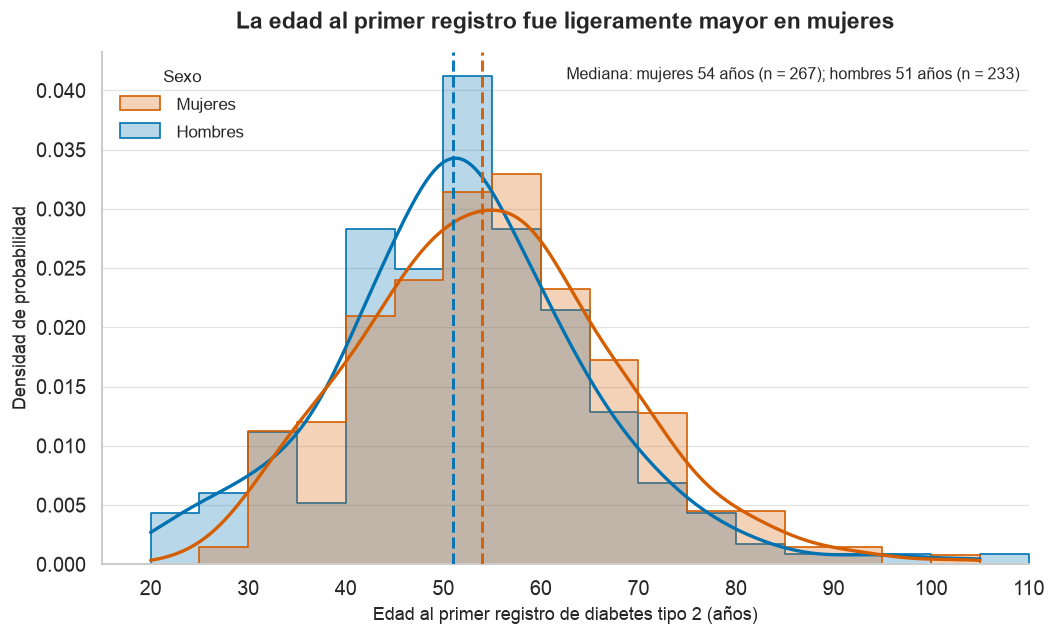

In [14]:
# Distribución de edad al primer registro de diabetes tipo 2, por sexo

orden_sexo = ["Mujeres", "Hombres"]

# Estadísticos utilizados en la anotación
resumen_figura_edad = (
    cohorte
    .groupby("sexo", observed=True)["edad_indice"]
    .agg(
        n="count",
        mediana="median",
    )
    .reindex(orden_sexo)
)

# Crear figura
fig, ax = plt.subplots(figsize=(9, 5.5))

sns.histplot(
    data=cohorte,
    x="edad_indice",
    hue="sexo",
    hue_order=orden_sexo,
    palette=COLORES_SEXO,
    bins=np.arange(15, 111, 5),
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.28,
    kde=True,
    kde_kws={
        "cut": 0,
        "bw_adjust": 1,
    },
    line_kws={
        "linewidth": 2,
    },
    ax=ax,
)

# Líneas verticales correspondientes a las medianas
for grupo in orden_sexo:
    mediana = resumen_figura_edad.loc[grupo, "mediana"]

    ax.axvline(
        x=mediana,
        color=COLORES_SEXO[grupo],
        linestyle="--",
        linewidth=1.8,
        alpha=0.95,
        zorder=5,
    )

# Estadísticos para la anotación
mediana_mujeres = resumen_figura_edad.loc["Mujeres", "mediana"]
mediana_hombres = resumen_figura_edad.loc["Hombres", "mediana"]

n_mujeres = int(resumen_figura_edad.loc["Mujeres", "n"])
n_hombres = int(resumen_figura_edad.loc["Hombres", "n"])

texto_resumen = (
    f"Mediana: mujeres {mediana_mujeres:.0f} años "
    f"(n = {n_mujeres}); hombres {mediana_hombres:.0f} años "
    f"(n = {n_hombres})"
)

# Título y etiquetas
ax.set_title(
    "La edad al primer registro fue ligeramente mayor en mujeres",
    fontsize=14,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel(
    "Edad al primer registro de diabetes tipo 2 (años)",
    fontsize=11,
)

ax.set_ylabel(
    "Densidad de probabilidad",
    fontsize=11,
)

# Escala completa, sin truncar edades observadas
ax.set_xlim(15, 110)
ax.set_xticks(np.arange(20, 111, 10))

# Anotación dinámica
ax.text(
    0.99,
    0.97,
    texto_resumen,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9.5,
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "none",
        "alpha": 0.85,
    },
)

# Corregir título y formato de la leyenda
leyenda = ax.get_legend()

if leyenda is not None:
    leyenda.set_title("Sexo")
    leyenda.get_title().set_fontsize(10)

    for texto in leyenda.get_texts():
        texto.set_fontsize(10)

# Ajustes visuales
ax.grid(
    axis="y",
    color="#BFBFBF",
    linewidth=0.7,
    alpha=0.45,
)

ax.grid(
    axis="x",
    visible=False,
)

sns.despine(
    ax=ax,
    top=True,
    right=True,
)

fig.tight_layout()

plt.show()

**Interpretación preliminar:** La distribución de edad mostró un patrón central semejante entre ambos sexos,
aunque las mujeres tuvieron una mediana tres años mayor que los hombres representado por lineas discontinuas del color atribuido al sexo biológico
(54 frente a 51 años). La mayor parte de la cohorte se concentró en edades
adultas medias, con una cola de pacientes longevos en ambos grupos.

## Evolución temporal de la hemoglobina glucosilada

Se seleccionó la hemoglobina glucosilada (HbA1c) como analito de interés,
identificada mediante el código LOINC `4548-4`. El archivo de observaciones
se procesó por bloques para conservar únicamente las mediciones pertenecientes
a los pacientes de la cohorte.

In [15]:
#Función para extraer HbA1c por bloques
CODIGO_HBA1C = "4548-4"
ids_cohorte = set(cohorte["Id"])

bloques_hba1c = []

for numero_bloque, bloque in enumerate(
    pd.read_csv(
        OBSERVATIONS_FILE,
        usecols=[
            "DATE",
            "PATIENT",
            "CODE",
            "DESCRIPTION",
            "VALUE",
            "UNITS",
            "TYPE",
        ],
        dtype="string",
        chunksize=250_000,
    ),
    start=1,
):
    mascara = (
        bloque["PATIENT"].isin(ids_cohorte)
        & bloque["CODE"].eq(CODIGO_HBA1C)
    )

    if mascara.any():
        bloques_hba1c.append(
            bloque.loc[mascara].copy()
        )

    if numero_bloque % 20 == 0:
        print(f"Bloques procesados: {numero_bloque}")

hba1c = pd.concat(
    bloques_hba1c,
    ignore_index=True,
)

print("Extracción terminada.")
print(f"Mediciones recuperadas: {len(hba1c):,}")
print(f"Pacientes con HbA1c: {hba1c['PATIENT'].nunique():,}")

Bloques procesados: 20
Bloques procesados: 40
Bloques procesados: 60
Extracción terminada.
Mediciones recuperadas: 11,231
Pacientes con HbA1c: 500


In [16]:
#Convertir fechas y valores
hba1c["DATE"] = pd.to_datetime(
    hba1c["DATE"],
    errors="coerce",
    utc=True,
).dt.tz_convert(None)

hba1c["HbA1c"] = pd.to_numeric(
    hba1c["VALUE"],
    errors="coerce",
)

print("Descripción:")
print(hba1c["DESCRIPTION"].value_counts(dropna=False))

print("\nUnidades:")
print(hba1c["UNITS"].value_counts(dropna=False))

print("\nTipos:")
print(hba1c["TYPE"].value_counts(dropna=False))

print("\nValores no numéricos:")
print(hba1c["HbA1c"].isna().sum())

Descripción:
DESCRIPTION
Hemoglobin A1c/Hemoglobin.total in Blood    11231
Name: count, dtype: Int64

Unidades:
UNITS
%    11231
Name: count, dtype: Int64

Tipos:
TYPE
numeric    11231
Name: count, dtype: Int64

Valores no numéricos:
0


In [17]:
#Resumen de cobertura
cobertura_hba1c = pd.Series({
    "pacientes_cohorte": cohorte["Id"].nunique(),
    "pacientes_con_hba1c": hba1c["PATIENT"].nunique(),
    "pacientes_sin_hba1c": (
        cohorte["Id"].nunique()
        - hba1c["PATIENT"].nunique()
    ),
    "mediciones_totales": len(hba1c),
    "mediana_mediciones_por_paciente": (
        hba1c.groupby("PATIENT").size().median()
    ),
    "maximo_mediciones_por_paciente": (
        hba1c.groupby("PATIENT").size().max()
    ),
})

cobertura_hba1c

pacientes_cohorte                    500.0
pacientes_con_hba1c                  500.0
pacientes_sin_hba1c                    0.0
mediciones_totales                 11231.0
mediana_mediciones_por_paciente       11.0
maximo_mediciones_por_paciente       350.0
dtype: float64

In [18]:
#Distribución numérica inicial
hba1c["HbA1c"].describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99,
    ]
)

count     11231.0
mean     4.835491
std      1.588623
min           2.3
1%            2.4
5%            2.4
25%           3.6
50%           4.6
75%           6.1
95%           7.1
99%           7.6
max          10.9
Name: HbA1c, dtype: Float64

### Preparación del análisis temporal

Las mediciones se alinearon respecto de la fecha índice individual. Los valores
negativos representan mediciones anteriores al primer encuentro relacionado
con diabetes y los positivos corresponden a mediciones posteriores.

Debido a la variabilidad en el número de mediciones por paciente, antes de
calcular una tendencia poblacional se evaluó la cobertura temporal y la
frecuencia individual de seguimiento.

In [19]:
#Incorporamos fecha índice
hba1c = hba1c.merge(
    fecha_indice.rename(
        columns={"fecha_indice": "fecha_indice_paciente"}
    ),
    left_on="PATIENT",
    right_on="Id",
    how="left",
    validate="many_to_one",
    indicator=True,
)

assert hba1c["_merge"].eq("both").all()

hba1c = hba1c.drop(
    columns=["Id", "_merge"]
)

hba1c["dias_desde_indice"] = (
    hba1c["DATE"]
    - hba1c["fecha_indice_paciente"]
).dt.total_seconds() / 86_400

hba1c["anios_desde_indice"] = (
    hba1c["dias_desde_indice"] / 365.2425
)

hba1c[
    [
        "PATIENT",
        "DATE",
        "fecha_indice_paciente",
        "dias_desde_indice",
        "HbA1c",
    ]
].head()

,PATIENT,DATE,fecha_indice_paciente,dias_desde_indice,HbA1c
0,8d3ebc60-a184-ee6f-4366-e81e0f7ba3bd,2016-10-09 12:39:23,2022-05-22 12:39:23,-2051.0,6.4
1,8d3ebc60-a184-ee6f-4366-e81e0f7ba3bd,2017-10-15 12:39:23,2022-05-22 12:39:23,-1680.0,5.8
2,8d3ebc60-a184-ee6f-4366-e81e0f7ba3bd,2018-03-11 12:39:23,2022-05-22 12:39:23,-1533.0,5.9
3,8d3ebc60-a184-ee6f-4366-e81e0f7ba3bd,2018-03-18 12:39:23,2022-05-22 12:39:23,-1526.0,6.2
4,8d3ebc60-a184-ee6f-4366-e81e0f7ba3bd,2018-10-21 12:39:23,2022-05-22 12:39:23,-1309.0,6.1


In [20]:
#Cobertura antes y después del índice
resumen_relacion_indice = pd.Series({
    "mediciones_antes": (
        hba1c["dias_desde_indice"] < 0
    ).sum(),
    "mediciones_mismo_dia": (
        hba1c["dias_desde_indice"].abs() < 1
    ).sum(),
    "mediciones_despues": (
        hba1c["dias_desde_indice"] > 0
    ).sum(),
    "pacientes_con_medicion_previa": (
        hba1c.loc[
            hba1c["dias_desde_indice"] < 0,
            "PATIENT",
        ].nunique()
    ),
    "pacientes_con_medicion_posterior": (
        hba1c.loc[
            hba1c["dias_desde_indice"] > 0,
            "PATIENT",
        ].nunique()
    ),
    "primer_tiempo_relativo_anios": (
        hba1c["anios_desde_indice"].min()
    ),
    "ultimo_tiempo_relativo_anios": (
        hba1c["anios_desde_indice"].max()
    ),
})

resumen_relacion_indice.round(2)

mediciones_antes                    2481.00
mediciones_mismo_dia                   1.00
mediciones_despues                  8750.00
pacientes_con_medicion_previa        448.00
pacientes_con_medicion_posterior     454.00
primer_tiempo_relativo_anios          -9.26
ultimo_tiempo_relativo_anios          54.79
dtype: float64

In [21]:
#Distribución de mediciones por paciente
mediciones_por_paciente = (
    hba1c
    .groupby("PATIENT")
    .size()
    .rename("n_mediciones")
    .reset_index()
)

mediciones_por_paciente["n_mediciones"].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

count    500.000000
mean      22.462000
std       45.653928
min        1.000000
25%        8.000000
50%       11.000000
75%       15.000000
90%       37.000000
95%       91.050000
99%      286.170000
max      350.000000
Name: n_mediciones, dtype: float64

In [22]:
#Pacientes con más mediciones
mayor_seguimiento = (
    mediciones_por_paciente
    .nlargest(10, "n_mediciones")
    .merge(
        cohorte[
            ["Id", "sexo", "edad_indice"]
        ],
        left_on="PATIENT",
        right_on="Id",
        how="left",
        validate="one_to_one",
    )
    .drop(columns="Id")
)

mayor_seguimiento

,PATIENT,n_mediciones,sexo,edad_indice
0,61d36822-730e-9a6e-e53f-5437732f9fa6,350,Mujeres,46
1,8b6ae548-ee9b-99cc-a919-1c0dad220bad,326,Hombres,62
2,8abe9929-66ea-8e0a-cb53-9ed9d1e55678,318,Hombres,76
3,d6fa21b1-de5c-7769-41b1-369b119bba61,311,Mujeres,65
4,10c07041-6486-a162-9937-48f8f45c653e,303,Hombres,69
5,2e02d976-85be-88da-502b-5d7986db3ea6,286,Mujeres,69
6,b96b75a5-176a-ad77-4154-cd4ebff9574c,264,Hombres,46
7,2ba887d9-aac8-7ea4-b87f-a2bc1948e4ff,250,Hombres,27
8,7b65a231-8d64-a008-0250-733b3c73be42,239,Mujeres,37
9,23128185-bbde-efb4-02cd-c52536f12fef,221,Hombres,71


In [23]:
#Mediciones repetidas en una fecha
repeticiones_fecha = (
    hba1c
    .groupby(
        ["PATIENT", "DATE"],
        as_index=False,
    )
    .agg(
        n_registros=("HbA1c", "size"),
        minimo=("HbA1c", "min"),
        maximo=("HbA1c", "max"),
        valores_unicos=("HbA1c", "nunique"),
    )
)

duplicados_misma_fecha = repeticiones_fecha.loc[
    repeticiones_fecha["n_registros"] > 1
]

print(
    "Combinaciones paciente-fecha repetidas:",
    f"{len(duplicados_misma_fecha):,}",
)

print(
    "Repeticiones con valores diferentes:",
    f"{(duplicados_misma_fecha['valores_unicos'] > 1).sum():,}",
)

duplicados_misma_fecha.head(10)

Combinaciones paciente-fecha repetidas: 0
Repeticiones con valores diferentes: 0


,PATIENT,DATE,n_registros,minimo,maximo,valores_unicos


### Estrategia de agregación temporal

El número de mediciones por paciente fue marcadamente desigual. Para impedir
que los pacientes con seguimiento intensivo dominaran la tendencia, se calculó
primero la mediana anual de HbA1c de cada paciente. Posteriormente se resumieron
esas medianas individuales a nivel de cohorte.

El año 0 representa los primeros 365 días a partir del encuentro índice. Los
años negativos corresponden al periodo anterior.

In [24]:
#Crear intervalos anuales
hba1c["anio_relativo"] = np.floor(
    hba1c["anios_desde_indice"]
).astype("Int64")

hba1c_paciente_anio = (
    hba1c
    .groupby(
        ["PATIENT", "anio_relativo"],
        as_index=False,
        observed=True,
    )
    .agg(
        hba1c_mediana_paciente=("HbA1c", "median"),
        n_mediciones=("HbA1c", "size"),
    )
)

assert not hba1c_paciente_anio.duplicated(
    subset=["PATIENT", "anio_relativo"]
).any()

hba1c_paciente_anio.head()

,PATIENT,anio_relativo,hba1c_mediana_paciente,n_mediciones
0,003bfc26-eb7d-8817-99a0-575e7765cf2c,4,5.8,1
1,003bfc26-eb7d-8817-99a0-575e7765cf2c,5,5.9,1
2,003bfc26-eb7d-8817-99a0-575e7765cf2c,6,6.0,1
3,003bfc26-eb7d-8817-99a0-575e7765cf2c,7,6.0,3
4,003bfc26-eb7d-8817-99a0-575e7765cf2c,8,6.0,3


In [25]:
#Resumen anual de la cohorte
evolucion_hba1c = (
    hba1c_paciente_anio
    .groupby(
        "anio_relativo",
        as_index=False,
        observed=True,
    )
    .agg(
        pacientes=("PATIENT", "nunique"),
        mediana_hba1c=(
            "hba1c_mediana_paciente",
            "median",
        ),
        q1_hba1c=(
            "hba1c_mediana_paciente",
            lambda x: x.quantile(0.25),
        ),
        q3_hba1c=(
            "hba1c_mediana_paciente",
            lambda x: x.quantile(0.75),
        ),
    )
)

ventana_hba1c = evolucion_hba1c.loc[
    evolucion_hba1c["anio_relativo"].between(-5, 10)
].copy()

ventana_hba1c

,anio_relativo,pacientes,mediana_hba1c,q1_hba1c,q3_hba1c
5,-5,198,6.1,6.0,6.3
6,-4,232,6.1,6.0,6.3
7,-3,265,6.1,5.9,6.3
8,-2,268,6.1,5.95,6.3
9,-1,448,7.1,6.9,7.5
10,0,380,6.9,6.1,7.0
11,1,356,6.8,6.0,7.0
12,2,280,6.6,5.8,7.0
13,3,211,6.1,5.6,7.0
14,4,207,6.1,5.6,6.9


/var/folders/pd/q0g0l1bs3_30q5gs20qtcs5m0000gn/T/ipykernel_15213/3422362308.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


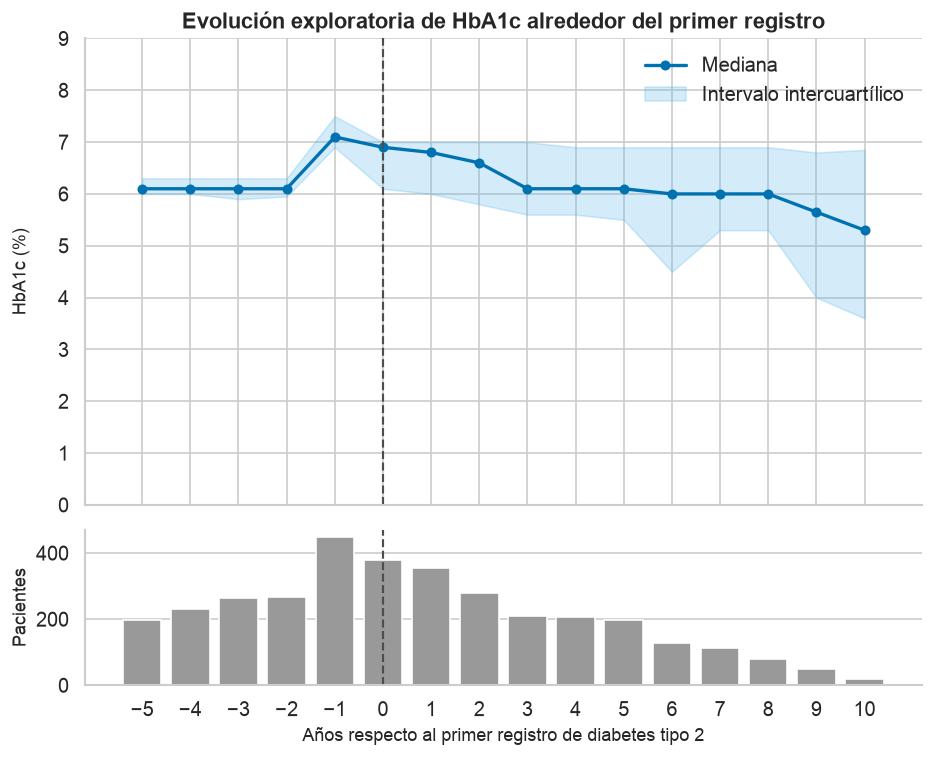

In [26]:
fig, (ax_tendencia, ax_cobertura) = plt.subplots(
    2,
    1,
    figsize=(9, 7),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3, 1],
        "hspace": 0.08,
    },
)

# Panel superior: evolución de HbA1c
ax_tendencia.plot(
    ventana_hba1c["anio_relativo"],
    ventana_hba1c["mediana_hba1c"],
    color="#0072B2",
    marker="o",
    markersize=5,
    linewidth=2,
    label="Mediana",
)

ax_tendencia.fill_between(
    ventana_hba1c["anio_relativo"].astype(float),
    ventana_hba1c["q1_hba1c"].astype(float),
    ventana_hba1c["q3_hba1c"].astype(float),
    color="#56B4E9",
    alpha=0.25,
    label="Intervalo intercuartílico",
)

ax_tendencia.axvline(
    0,
    color="#4D4D4D",
    linestyle="--",
    linewidth=1.3,
)

ax_tendencia.set(
    title="Evolución exploratoria de HbA1c alrededor del primer registro",
    ylabel="HbA1c (%)",
)

ax_tendencia.set_ylim(
    0,
    max(
        9,
        float(ventana_hba1c["q3_hba1c"].max()) + 1,
    ),
)

ax_tendencia.legend(
    loc="upper right",
    title=None,
)

# Panel inferior: pacientes representados
ax_cobertura.bar(
    ventana_hba1c["anio_relativo"],
    ventana_hba1c["pacientes"],
    color="#999999",
    width=0.8,
)

ax_cobertura.axvline(
    0,
    color="#4D4D4D",
    linestyle="--",
    linewidth=1.3,
)

ax_cobertura.set(
    xlabel="Años respecto al primer registro de diabetes tipo 2",
    ylabel="Pacientes",
)

ax_cobertura.set_xticks(
    np.arange(-5, 11, 1)
)

ax_cobertura.grid(
    axis="x",
    visible=False,
)

sns.despine(ax=ax_tendencia)
sns.despine(ax=ax_cobertura)

fig.align_ylabels(
    [ax_tendencia, ax_cobertura]
)

fig.tight_layout()

plt.show()

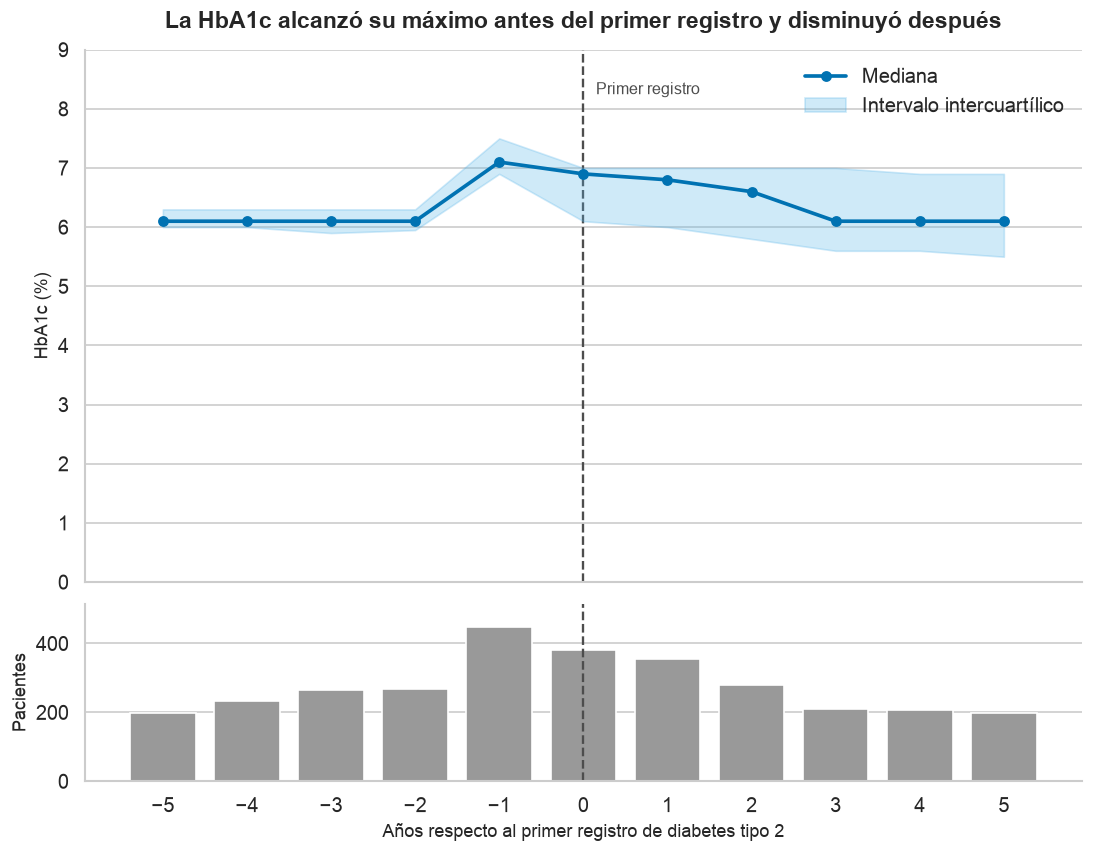

In [27]:
# Evolución de HbA1c alrededor del primer registro de diabetes tipo 2

VENTANA_INICIAL = -5
VENTANA_FINAL = 5

ventana_final_hba1c = evolucion_hba1c.loc[
    evolucion_hba1c["anio_relativo"].between(
        VENTANA_INICIAL,
        VENTANA_FINAL,
    )
].copy()

# Validar cobertura mínima dentro de la ventana
assert ventana_final_hba1c["pacientes"].min() >= 100

fig, (ax_tendencia, ax_cobertura) = plt.subplots(
    2,
    1,
    figsize=(9, 7),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3, 1],
    },
    layout="constrained",
)

# Panel superior: mediana e intervalo intercuartílico

ax_tendencia.plot(
    ventana_final_hba1c["anio_relativo"],
    ventana_final_hba1c["mediana_hba1c"],
    color="#0072B2",
    marker="o",
    markersize=5.5,
    linewidth=2.2,
    label="Mediana",
    zorder=3,
)

ax_tendencia.fill_between(
    ventana_final_hba1c["anio_relativo"].astype(float),
    ventana_final_hba1c["q1_hba1c"].astype(float),
    ventana_final_hba1c["q3_hba1c"].astype(float),
    color="#56B4E9",
    alpha=0.28,
    label="Intervalo intercuartílico",
    zorder=2,
)

# Línea de la fecha índice
ax_tendencia.axvline(
    x=0,
    color="#4D4D4D",
    linestyle="--",
    linewidth=1.4,
    zorder=1,
)

ax_tendencia.text(
    0.15,
    8.45,
    "Primer registro",
    color="#4D4D4D",
    fontsize=9.5,
    ha="left",
    va="top",
)

ax_tendencia.set_title(
    "La HbA1c alcanzó su máximo antes del primer registro y disminuyó después",
    fontsize=13.5,
    fontweight="bold",
    pad=13,
)

ax_tendencia.set_ylabel(
    "HbA1c (%)",
    fontsize=11,
)

# El eje comienza en cero para evitar una exageración visual del cambio
ax_tendencia.set_ylim(0, 9)

ax_tendencia.legend(
    loc="upper right",
    frameon=False,
)

ax_tendencia.grid(
    axis="x",
    visible=False,
)

# Panel inferior: cobertura

ax_cobertura.bar(
    ventana_final_hba1c["anio_relativo"],
    ventana_final_hba1c["pacientes"],
    color="#999999",
    width=0.78,
)

ax_cobertura.axvline(
    x=0,
    color="#4D4D4D",
    linestyle="--",
    linewidth=1.4,
)

ax_cobertura.set_xlabel(
    "Años respecto al primer registro de diabetes tipo 2",
    fontsize=11,
)

ax_cobertura.set_ylabel(
    "Pacientes",
    fontsize=11,
)

ax_cobertura.set_xticks(
    np.arange(
        VENTANA_INICIAL,
        VENTANA_FINAL + 1,
        1,
    )
)

ax_cobertura.set_ylim(
    0,
    ventana_final_hba1c["pacientes"].max() * 1.15,
)

ax_cobertura.grid(
    axis="x",
    visible=False,
)

sns.despine(ax=ax_tendencia)
sns.despine(ax=ax_cobertura)

plt.show()

**Nota:** La mediana de HbA1c fue de aproximadamente 6.1 % entre cinco y dos años
antes del primer registro relacionado con diabetes tipo 2. Durante el año
inmediatamente anterior aumentó hasta 7.1 %, seguido de una disminución a
6.9 % durante el primer año posterior y a 6.1 % entre los años tres y cinco.

El aumento previo al registro es compatible con la identificación de la
enfermedad después de una elevación del analito. Sin embargo, este análisis
es descriptivo y no permite atribuir el descenso posterior a una intervención
específica.

La cobertura disminuyó conforme aumentó el seguimiento. Por ello, la figura
final se restringió a cinco años antes y cinco años después del índice, periodo
en el que cada intervalo incluyó al menos 198 pacientes.

## Comorbilidades registradas antes de la fecha índice

Debido a que la cohorte original no incluyó la tabla `conditions.csv`, las
comorbilidades se identificaron mediante los códigos y descripciones registrados
como motivo de los encuentros clínicos.

Para mantener una definición basal, solamente se consideraron diagnósticos
registrados hasta la fecha índice inclusive. Se excluyeron los códigos empleados
para definir diabetes tipo 2. La prevalencia representa la proporción de
pacientes con al menos un registro de cada diagnóstico y no el número total
de encuentros.

In [28]:
#Extraer diagnósticos de la cohorte
bloques_diagnosticos = []

for numero_bloque, bloque in enumerate(
    pd.read_csv(
        ENCOUNTERS_FILE,
        usecols=[
            "START",
            "PATIENT",
            "REASONCODE",
            "REASONDESCRIPTION",
        ],
        dtype={
            "START": "string",
            "PATIENT": "string",
            "REASONCODE": "string",
            "REASONDESCRIPTION": "string",
        },
        chunksize=100_000,
    ),
    start=1,
):
    mascara = (
        bloque["PATIENT"].isin(ids_cohorte)
        & bloque["REASONCODE"].notna()
        & bloque["REASONDESCRIPTION"].notna()
    )

    if mascara.any():
        bloques_diagnosticos.append(
            bloque.loc[mascara].copy()
        )

    if numero_bloque % 5 == 0:
        print(f"Bloques procesados: {numero_bloque}")

diagnosticos_cohorte = pd.concat(
    bloques_diagnosticos,
    ignore_index=True,
)

print("Extracción terminada.")
print(
    "Encuentros con motivo diagnóstico:",
    f"{len(diagnosticos_cohorte):,}",
)
print(
    "Pacientes representados:",
    f"{diagnosticos_cohorte['PATIENT'].nunique():,}",
)

Bloques procesados: 5
Bloques procesados: 10
Extracción terminada.
Encuentros con motivo diagnóstico: 19,769
Pacientes representados: 500


In [29]:
#Incorporamos la fecha índice
diagnosticos_cohorte["START"] = pd.to_datetime(
    diagnosticos_cohorte["START"],
    errors="coerce",
    utc=True,
).dt.tz_convert(None)

diagnosticos_cohorte = diagnosticos_cohorte.merge(
    fecha_indice.rename(
        columns={"fecha_indice": "fecha_indice_paciente"}
    ),
    left_on="PATIENT",
    right_on="Id",
    how="left",
    validate="many_to_one",
    indicator=True,
)

assert diagnosticos_cohorte["_merge"].eq("both").all()

diagnosticos_cohorte = diagnosticos_cohorte.drop(
    columns=["Id", "_merge"]
)

print(
    "Fechas de encuentro faltantes:",
    diagnosticos_cohorte["START"].isna().sum(),
)

Fechas de encuentro faltantes: 0


In [30]:
#Conmorbilidades basales
comorbilidades_basales = diagnosticos_cohorte.loc[
    (
        diagnosticos_cohorte["START"]
        <= diagnosticos_cohorte["fecha_indice_paciente"]
    )
    & ~diagnosticos_cohorte["REASONCODE"].isin(
        CODIGOS_DIABETES_T2
    )
].copy()

print(
    "Registros diagnósticos basales no diabéticos:",
    f"{len(comorbilidades_basales):,}",
)

print(
    "Pacientes con al menos una comorbilidad registrada:",
    f"{comorbilidades_basales['PATIENT'].nunique():,}",
)

Registros diagnósticos basales no diabéticos: 8,685
Pacientes con al menos una comorbilidad registrada: 493


In [31]:
#Función para calcular la prevalencia por paciente
resumen_comorbilidades = (
    comorbilidades_basales[
        [
            "PATIENT",
            "REASONCODE",
            "REASONDESCRIPTION",
        ]
    ]
    .drop_duplicates()
    .groupby(
        ["REASONCODE", "REASONDESCRIPTION"],
        as_index=False,
        dropna=False,
    )
    .agg(
        pacientes=("PATIENT", "nunique"),
    )
)

resumen_comorbilidades["prevalencia_pct"] = (
    resumen_comorbilidades["pacientes"]
    / cohorte["Id"].nunique()
    * 100
)

resumen_comorbilidades = (
    resumen_comorbilidades
    .sort_values(
        ["pacientes", "REASONDESCRIPTION"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

resumen_comorbilidades.head(25)

,REASONCODE,REASONDESCRIPTION,pacientes,prevalencia_pct
0,103697008,Patient referral for dental care (procedure),288,57.6
1,66383009,Gingivitis (disorder),281,56.2
2,444814009,Viral sinusitis (disorder),186,37.2
3,275978004,Screening for malignant neoplasm of colon (pro...,176,35.2
4,271737000,Anemia (disorder),141,28.2
5,82423001,Chronic pain (finding),138,27.6
6,195662009,Acute viral pharyngitis (disorder),126,25.2
7,389095005,Contraception care (regime/therapy),112,22.4
8,10509002,Acute bronchitis (disorder),111,22.2
9,414545008,Ischemic heart disease (disorder),94,18.8


In [32]:
#Seleccionamos aquellas comorbilidades persistentes excluyendo eventos agudos, procedimientos y situaciones asistenciales
# Expresiones correspondientes a eventos agudos o no considerados
# comorbilidades persistentes para este análisis
PATRON_EXCLUSION_COMORBILIDADES = (
    r"acute|viral sinusitis|sinusitis|pregnancy|miscarriage|"
    r"blighted ovum|contraception|sterilization|referral|"
    r"screening|patient transfer|diagnostic imaging"
)

mascara_entidad_clinica = (
    resumen_comorbilidades["REASONDESCRIPTION"]
    .str.contains(
        r"\((?:disorder|finding)\)$",
        case=False,
        na=False,
        regex=True,
    )
)

mascara_exclusion = (
    resumen_comorbilidades["REASONDESCRIPTION"]
    .str.contains(
        PATRON_EXCLUSION_COMORBILIDADES,
        case=False,
        na=False,
        regex=True,
    )
)

comorbilidades_persistentes = (
    resumen_comorbilidades.loc[
        mascara_entidad_clinica & ~mascara_exclusion
    ]
    .copy()
    .sort_values(
        ["pacientes", "REASONDESCRIPTION"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

comorbilidades_persistentes.head(20)

,REASONCODE,REASONDESCRIPTION,pacientes,prevalencia_pct
0,66383009,Gingivitis (disorder),281,56.2
1,271737000,Anemia (disorder),141,28.2
2,82423001,Chronic pain (finding),138,27.6
3,414545008,Ischemic heart disease (disorder),94,18.8
4,609328004,Allergic disposition (finding),81,16.2
5,55822004,Hyperlipidemia (disorder),75,15.0
6,39898005,Sleep disorder (disorder),43,8.6
7,239873007,Osteoarthritis of knee (disorder),41,8.2
8,124171000119105,Chronic intractable migraine without aura (dis...,32,6.4
9,6525002,Dependent drug abuse (disorder),31,6.2


In [33]:
#Registramos las diez comorbilidades principales
top_comorbilidades = (
    comorbilidades_persistentes
    .head(10)
    .copy()
)

TRADUCCION_COMORBILIDADES = {
    "Gingivitis (disorder)": "Gingivitis",
    "Anemia (disorder)": "Anemia",
    "Chronic pain (finding)": "Dolor crónico",
    "Ischemic heart disease (disorder)": "Cardiopatía isquémica",
    "Allergic disposition (finding)": "Predisposición alérgica",
    "Hyperlipidemia (disorder)": "Hiperlipidemia",
    "Sleep disorder (disorder)": "Trastorno del sueño",
    "Osteoarthritis of knee (disorder)": "Osteoartritis de rodilla",
    "Chronic intractable migraine without aura (disorder)": (
        "Migraña crónica sin aura"
    ),
    "Dependent drug abuse (disorder)": "Dependencia de drogas",
    "Polyp of colon (disorder)": "Pólipo de colon",
}

top_comorbilidades["comorbilidad"] = (
    top_comorbilidades["REASONDESCRIPTION"]
    .map(TRADUCCION_COMORBILIDADES)
    .fillna(top_comorbilidades["REASONDESCRIPTION"])
)

top_comorbilidades[
    [
        "REASONCODE",
        "comorbilidad",
        "pacientes",
        "prevalencia_pct",
    ]
]

,REASONCODE,comorbilidad,pacientes,prevalencia_pct
0,66383009,Gingivitis,281,56.2
1,271737000,Anemia,141,28.2
2,82423001,Dolor crónico,138,27.6
3,414545008,Cardiopatía isquémica,94,18.8
4,609328004,Predisposición alérgica,81,16.2
5,55822004,Hiperlipidemia,75,15.0
6,39898005,Trastorno del sueño,43,8.6
7,239873007,Osteoartritis de rodilla,41,8.2
8,124171000119105,Migraña crónica sin aura,32,6.4
9,6525002,Dependencia de drogas,31,6.2


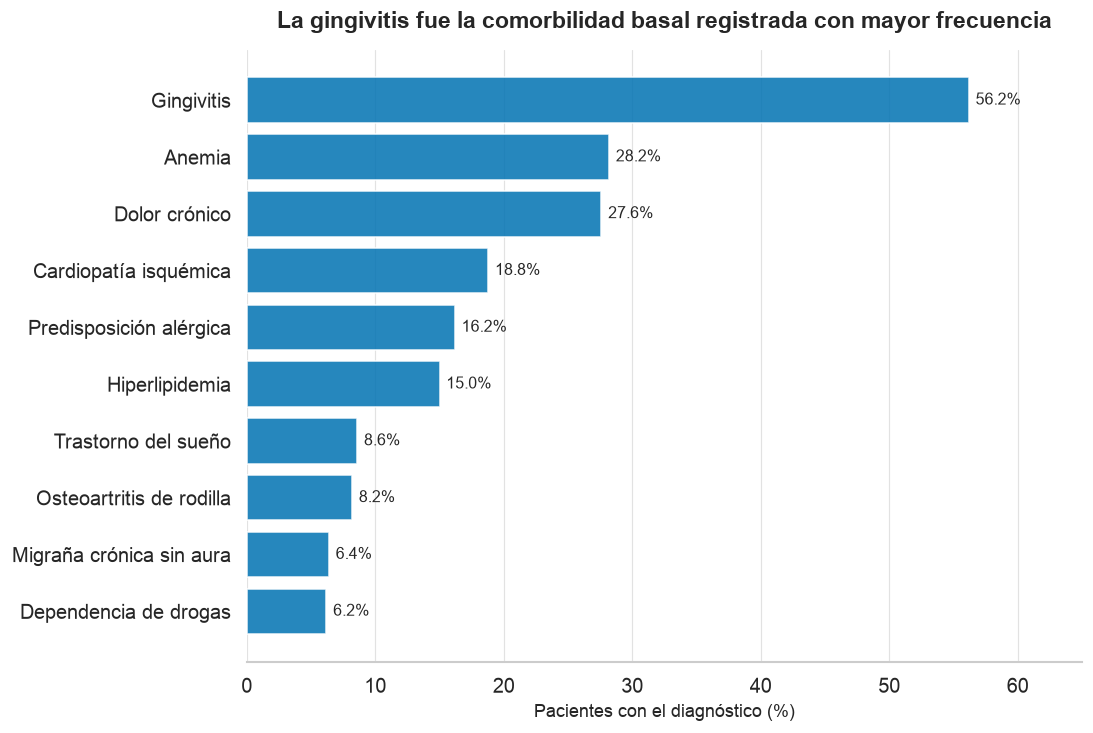

In [34]:
#Graficamos las conmorbilidades
top_comorbilidades_plot = (
    top_comorbilidades
    .sort_values(
        "prevalencia_pct",
        ascending=True,
    )
)

fig, ax = plt.subplots(
    figsize=(9, 6),
    layout="constrained",
)

barras = ax.barh(
    top_comorbilidades_plot["comorbilidad"],
    top_comorbilidades_plot["prevalencia_pct"],
    color="#0072B2",
    alpha=0.85,
)

ax.bar_label(
    barras,
    labels=[
        f"{valor:.1f}%"
        for valor in top_comorbilidades_plot["prevalencia_pct"]
    ],
    padding=4,
    fontsize=9.5,
)

ax.set_title(
    "La gingivitis fue la comorbilidad basal registrada con mayor frecuencia",
    fontsize=13.5,
    fontweight="bold",
    pad=13,
)

ax.set_xlabel(
    "Pacientes con el diagnóstico (%)",
    fontsize=11,
)

ax.set_ylabel("")

ax.set_xlim(
    0,
    max(
        65,
        top_comorbilidades_plot["prevalencia_pct"].max() + 8,
    ),
)

ax.grid(
    axis="x",
    color="#BFBFBF",
    linewidth=0.7,
    alpha=0.45,
)

ax.grid(
    axis="y",
    visible=False,
)

sns.despine(
    ax=ax,
    top=True,
    right=True,
    left=True,
)

plt.show()

**Interpretación:** De los 500 pacientes, 493 (98.6 %) presentaron al menos un diagnóstico basal
adicional registrado como motivo de encuentro. Después de excluir
procedimientos, situaciones asistenciales y procesos agudos, la gingivitis
fue la comorbilidad más frecuente. También destacaron la anemia, el dolor
crónico, la cardiopatía isquémica y la hiperlipidemia.

Estas prevalencias deben interpretarse como diagnósticos documentados en los
motivos de encuentro y no como una reconstrucción exhaustiva de la historia
clínica, ya que la cohorte original no incluyó la tabla `conditions.csv`. 

## 4. Problemas de calidad detectables mediante visualización

Además de revisar valores faltantes, rangos y estadísticos descriptivos, se
examinaron gráficamente la cobertura temporal y la distribución de las
mediciones individuales. Este procedimiento permite identificar patrones
estructurales que no aparecen en `describe()`.

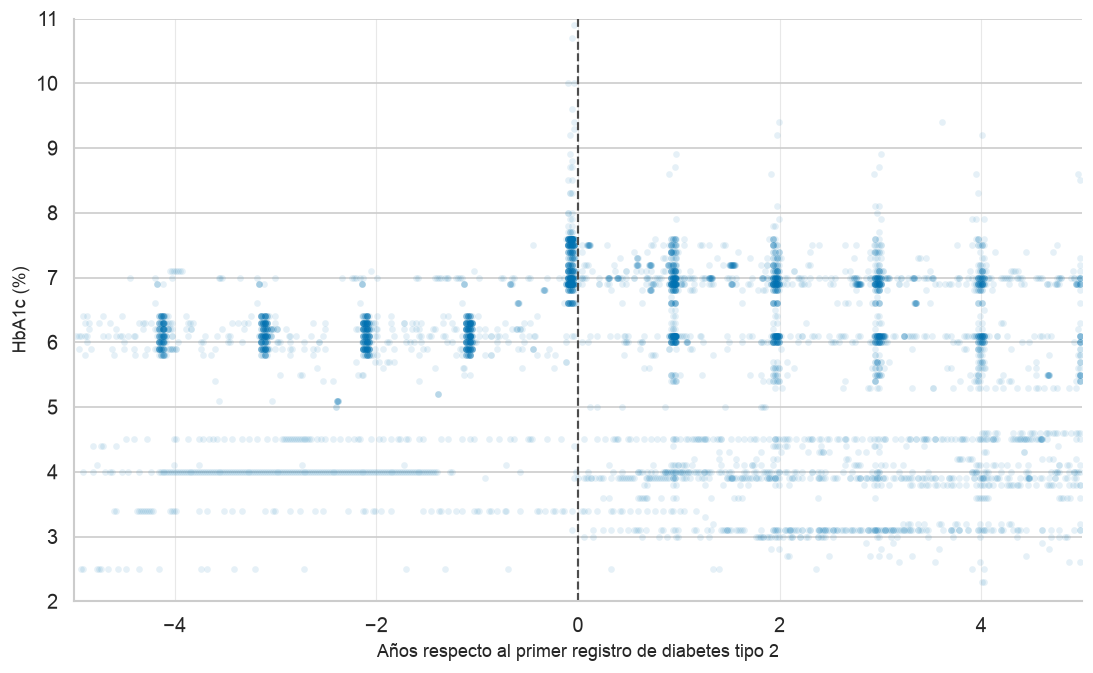

In [35]:
hba1c_ventana_individual = hba1c.loc[
    hba1c["anios_desde_indice"].between(-5, 5)
].copy()

fig, ax = plt.subplots(
    figsize=(9, 5.5),
    layout="constrained",
)

sns.scatterplot(
    data=hba1c_ventana_individual,
    x="anios_desde_indice",
    y="HbA1c",
    color="#0072B2",
    alpha=0.10,
    s=16,
    linewidth=0,
    ax=ax,
)

ax.axvline(
    x=0,
    color="#4D4D4D",
    linestyle="--",
    linewidth=1.3,
)

ax.set_xlabel(
    "Años respecto al primer registro de diabetes tipo 2",
    fontsize=11,
)

ax.set_ylabel(
    "HbA1c (%)",
    fontsize=11,
)

ax.set_xlim(-5, 5)
ax.set_ylim(2, 11)

ax.grid(
    axis="x",
    color="#BFBFBF",
    linewidth=0.7,
    alpha=0.35,
)

sns.despine(ax=ax)

plt.show()

In [36]:
diferencia_una_decimal = np.abs(
    hba1c["HbA1c"] * 10
    - np.round(hba1c["HbA1c"] * 10)
)

porcentaje_una_decimal = (
    np.isclose(
        diferencia_una_decimal,
        0,
        atol=1e-9,
    ).mean()
    * 100
)

print(
    "Mediciones compatibles con resolución de una décima:",
    f"{porcentaje_una_decimal:.1f}%",
)

print(
    "Número de valores distintos:",
    hba1c["HbA1c"].nunique(),
)

print(
    "Primeros valores posibles:",
    sorted(hba1c["HbA1c"].unique())[:20],
)

Mediciones compatibles con resolución de una décima: 100.0%
Número de valores distintos: 68
Primeros valores posibles: [np.float64(2.3), np.float64(2.4), np.float64(2.5), np.float64(2.6), np.float64(2.7), np.float64(2.8), np.float64(2.9), np.float64(3.0), np.float64(3.1), np.float64(3.2), np.float64(3.3), np.float64(3.4), np.float64(3.6), np.float64(3.8), np.float64(3.9), np.float64(4.0), np.float64(4.1), np.float64(4.2), np.float64(4.3), np.float64(4.4)]


La gráfica de observaciones individuales mostró bandas horizontales regulares.
La revisión posterior confirmó que los valores de HbA1c estaban discretizados
a una décima porcentual. Este patrón no era evidente en `describe()`, que
solamente resumía el rango y los cuantiles.

La discretización no invalida el análisis, pero reduce la variabilidad
continua del analito y puede producir empates en medianas y cuantiles.
Por ello, las diferencias pequeñas no deben interpretarse con una precisión
superior a 0.1 puntos porcentuales.

In [37]:
frecuencias_hba1c = (
    hba1c["HbA1c"]
    .value_counts()
    .rename_axis("HbA1c")
    .reset_index(name="mediciones")
)

frecuencias_hba1c.head(15)

,HbA1c,mediciones
0,2.5,780
1,3.9,679
2,6.1,661
3,4.0,591
4,2.4,567
5,6.9,517
6,7.0,488
7,3.1,484
8,6.0,469
9,5.5,428


La gráfica mostró que muchas mediciones de HbA1c se repiten en valores y
momentos específicos. Aunque reportar la HbA1c con una cifra decimal es
normal, la formación de bandas sugiere que los datos siguen patrones propios
de la simulación y no toda la variabilidad esperada en pacientes reales.

Este patrón no invalida el análisis, pero indica que los cambios pequeños
deben interpretarse con cautela.

## 5. Figura multipanel 2×2

#### Figura multipanel de la cohorte
Se integraron cuatro resultados principales en una figura 2×2: distribución
de edad por sexo, evolución temporal de HbA1c, comorbilidades basales y
cobertura del seguimiento. Cada panel presenta un título basado en su
hallazgo principal.

In [38]:
# Datos de comorbilidades para el panel C
top_8_comorbilidades = (
    top_comorbilidades
    .head(8)
    .sort_values(
        "prevalencia_pct",
        ascending=True,
    )
    .copy()
)

# Datos temporales para los paneles B y D
datos_temporales_multipanel = (
    evolucion_hba1c.loc[
        evolucion_hba1c["anio_relativo"].between(-5, 5)
    ]
    .copy()
)

# Comprobaciones
assert len(top_8_comorbilidades) == 8
assert datos_temporales_multipanel["pacientes"].min() >= 100

print("Comorbilidades incluidas:", len(top_8_comorbilidades))
print(
    "Intervalo temporal:",
    datos_temporales_multipanel["anio_relativo"].min(),
    "a",
    datos_temporales_multipanel["anio_relativo"].max(),
)

Comorbilidades incluidas: 8
Intervalo temporal: -5 a 5


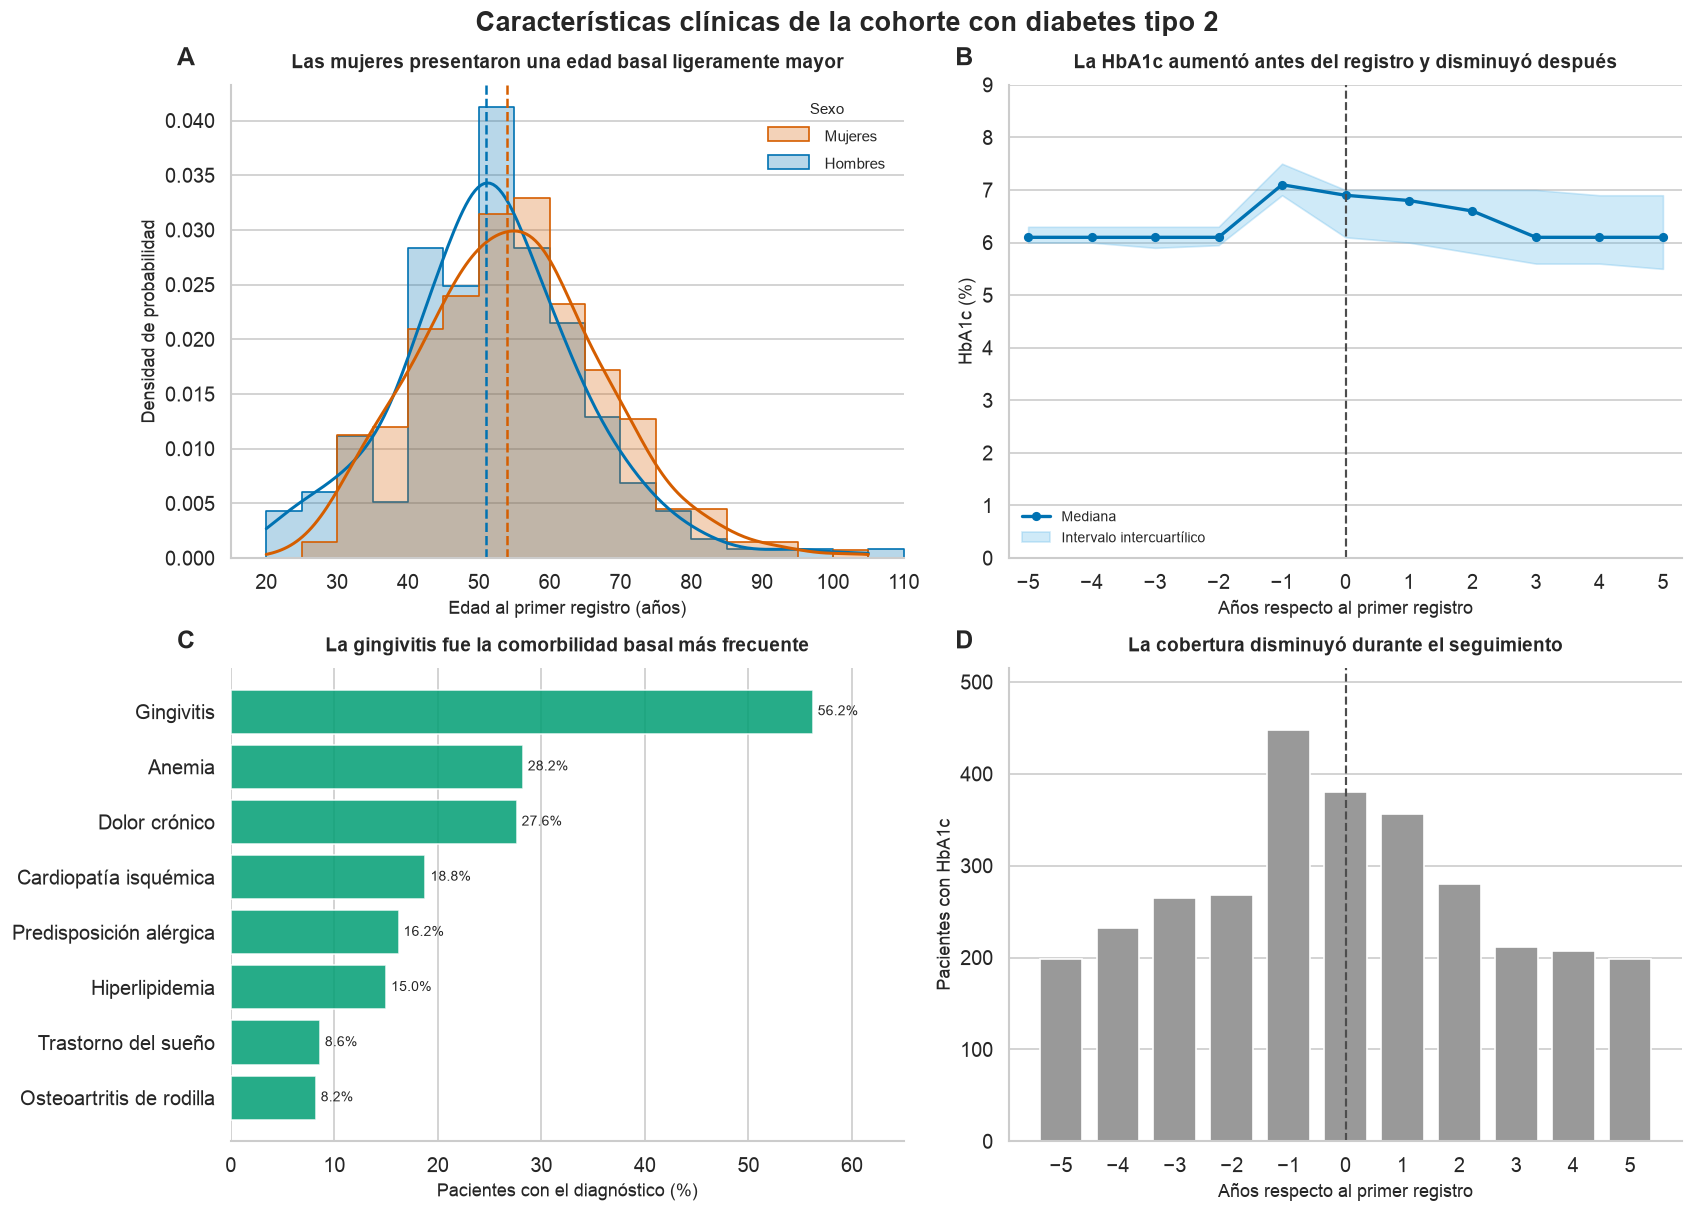

In [39]:
#Función para contruir la figura multipanel 2 × 2

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10),
    layout="constrained",
)

ax_a, ax_b = axes[0]
ax_c, ax_d = axes[1]

# Panel A — Distribución de edad

sns.histplot(
    data=cohorte,
    x="edad_indice",
    hue="sexo",
    hue_order=["Mujeres", "Hombres"],
    palette=COLORES_SEXO,
    bins=np.arange(15, 111, 5),
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.28,
    kde=True,
    kde_kws={
        "cut": 0,
        "bw_adjust": 1,
    },
    line_kws={
        "linewidth": 1.8,
    },
    ax=ax_a,
)

for grupo in ["Mujeres", "Hombres"]:
    mediana = resumen_figura_edad.loc[
        grupo,
        "mediana",
    ]

    ax_a.axvline(
        mediana,
        color=COLORES_SEXO[grupo],
        linestyle="--",
        linewidth=1.5,
    )

ax_a.set_title(
    "Las mujeres presentaron una edad basal ligeramente mayor",
    fontsize=11.5,
    fontweight="bold",
    pad=10,
)

ax_a.set_xlabel(
    "Edad al primer registro (años)"
)

ax_a.set_ylabel(
    "Densidad de probabilidad"
)

ax_a.set_xlim(15, 110)
ax_a.set_xticks(np.arange(20, 111, 10))

leyenda_a = ax_a.get_legend()

if leyenda_a is not None:
    leyenda_a.set_title("Sexo")
    leyenda_a.get_title().set_fontsize(9)

    for texto in leyenda_a.get_texts():
        texto.set_fontsize(9)

ax_a.grid(axis="x", visible=False)
sns.despine(ax=ax_a)

# Panel B — Evolución temporal de HbA1c

ax_b.plot(
    datos_temporales_multipanel["anio_relativo"],
    datos_temporales_multipanel["mediana_hba1c"],
    color="#0072B2",
    marker="o",
    markersize=4.5,
    linewidth=2,
    label="Mediana",
)

ax_b.fill_between(
    datos_temporales_multipanel["anio_relativo"].astype(float),
    datos_temporales_multipanel["q1_hba1c"].astype(float),
    datos_temporales_multipanel["q3_hba1c"].astype(float),
    color="#56B4E9",
    alpha=0.28,
    label="Intervalo intercuartílico",
)

ax_b.axvline(
    0,
    color="#4D4D4D",
    linestyle="--",
    linewidth=1.3,
)

ax_b.set_title(
    "La HbA1c aumentó antes del registro y disminuyó después",
    fontsize=11.5,
    fontweight="bold",
    pad=10,
)

ax_b.set_xlabel(
    "Años respecto al primer registro"
)

ax_b.set_ylabel(
    "HbA1c (%)"
)

ax_b.set_xlim(-5.3, 5.3)
ax_b.set_ylim(0, 9)
ax_b.set_xticks(np.arange(-5, 6, 1))

ax_b.legend(
    loc="lower left",
    fontsize=8.5,
    frameon=False,
)

ax_b.grid(axis="x", visible=False)
sns.despine(ax=ax_b)

# Panel C — Comorbilidades basales

barras_c = ax_c.barh(
    top_8_comorbilidades["comorbilidad"],
    top_8_comorbilidades["prevalencia_pct"],
    color="#009E73",
    alpha=0.85,
)

ax_c.bar_label(
    barras_c,
    labels=[
        f"{valor:.1f}%"
        for valor in top_8_comorbilidades["prevalencia_pct"]
    ],
    padding=3,
    fontsize=8.5,
)

ax_c.set_title(
    "La gingivitis fue la comorbilidad basal más frecuente",
    fontsize=11.5,
    fontweight="bold",
    pad=10,
)

ax_c.set_xlabel(
    "Pacientes con el diagnóstico (%)"
)

ax_c.set_ylabel("")

ax_c.set_xlim(
    0,
    max(
        65,
        top_8_comorbilidades["prevalencia_pct"].max() + 8,
    ),
)

ax_c.grid(axis="y", visible=False)
sns.despine(
    ax=ax_c,
    left=True,
)

# Panel D — Cobertura temporal

ax_d.bar(
    datos_temporales_multipanel["anio_relativo"],
    datos_temporales_multipanel["pacientes"],
    color="#999999",
    width=0.75,
)

ax_d.axvline(
    0,
    color="#4D4D4D",
    linestyle="--",
    linewidth=1.3,
)

ax_d.set_title(
    "La cobertura disminuyó durante el seguimiento",
    fontsize=11.5,
    fontweight="bold",
    pad=10,
)

ax_d.set_xlabel(
    "Años respecto al primer registro"
)

ax_d.set_ylabel(
    "Pacientes con HbA1c"
)

ax_d.set_xticks(np.arange(-5, 6, 1))

ax_d.set_ylim(
    0,
    datos_temporales_multipanel["pacientes"].max() * 1.15,
)

ax_d.grid(axis="x", visible=False)
sns.despine(ax=ax_d)

# Etiquetas de panel

for ax, etiqueta in zip(
    [ax_a, ax_b, ax_c, ax_d],
    ["A", "B", "C", "D"],
):
    ax.text(
        -0.08,
        1.08,
        etiqueta,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        ha="left",
        va="top",
    )

# Título general
fig.suptitle(
    "Características clínicas de la cohorte con diabetes tipo 2",
    fontsize=16,
    fontweight="bold",
)

plt.show()

**Nota:** La cohorte estuvo formada principalmente por adultos de mediana edad, con una
edad ligeramente mayor entre las mujeres. La HbA1c aumentó durante el año
anterior al primer registro de diabetes y disminuyó en los años posteriores.
La gingivitis fue la comorbilidad basal más frecuente.

La cobertura temporal fue máxima alrededor de la fecha índice y disminuyó
durante el seguimiento. Por ello, las estimaciones alejadas del primer
registro deben interpretarse con mayor cautela.

## 6. Comparación entre Matplotlib, Seaborn y Plotly

#### Comparación de bibliotecas de visualización

La distribución de edad por sexo se reprodujo mediante Matplotlib, Seaborn y
Plotly. Se mantuvieron los mismos datos, colores, intervalos, límites y medidas
de resumen para comparar el esfuerzo de programación, el control visual y el
resultado obtenido.

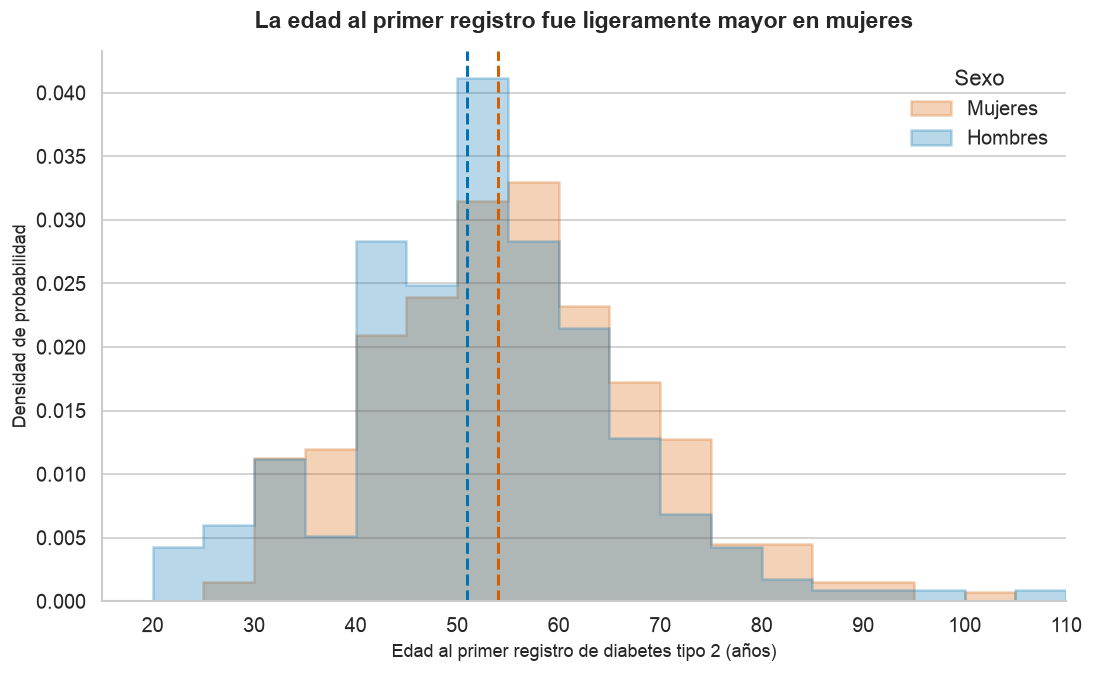

In [40]:
# Distribución de edad por sexo — Matplotlib puro

edades_mujeres = (
    cohorte.loc[
        cohorte["sexo"] == "Mujeres",
        "edad_indice",
    ]
    .dropna()
    .astype(float)
)

edades_hombres = (
    cohorte.loc[
        cohorte["sexo"] == "Hombres",
        "edad_indice",
    ]
    .dropna()
    .astype(float)
)

intervalos_edad = np.arange(15, 111, 5)

fig_matplotlib, ax = plt.subplots(
    figsize=(9, 5.5),
    layout="constrained",
)

ax.hist(
    edades_mujeres,
    bins=intervalos_edad,
    density=True,
    histtype="stepfilled",
    color=COLORES_SEXO["Mujeres"],
    edgecolor=COLORES_SEXO["Mujeres"],
    linewidth=1.5,
    alpha=0.28,
    label="Mujeres",
)

ax.hist(
    edades_hombres,
    bins=intervalos_edad,
    density=True,
    histtype="stepfilled",
    color=COLORES_SEXO["Hombres"],
    edgecolor=COLORES_SEXO["Hombres"],
    linewidth=1.5,
    alpha=0.28,
    label="Hombres",
)

ax.axvline(
    np.median(edades_mujeres),
    color=COLORES_SEXO["Mujeres"],
    linestyle="--",
    linewidth=1.8,
)

ax.axvline(
    np.median(edades_hombres),
    color=COLORES_SEXO["Hombres"],
    linestyle="--",
    linewidth=1.8,
)

ax.set_title(
    "La edad al primer registro fue ligeramente mayor en mujeres",
    fontsize=14,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel(
    "Edad al primer registro de diabetes tipo 2 (años)"
)

ax.set_ylabel(
    "Densidad de probabilidad"
)

ax.set_xlim(15, 110)
ax.set_xticks(np.arange(20, 111, 10))

ax.legend(
    title="Sexo",
    frameon=False,
)

ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

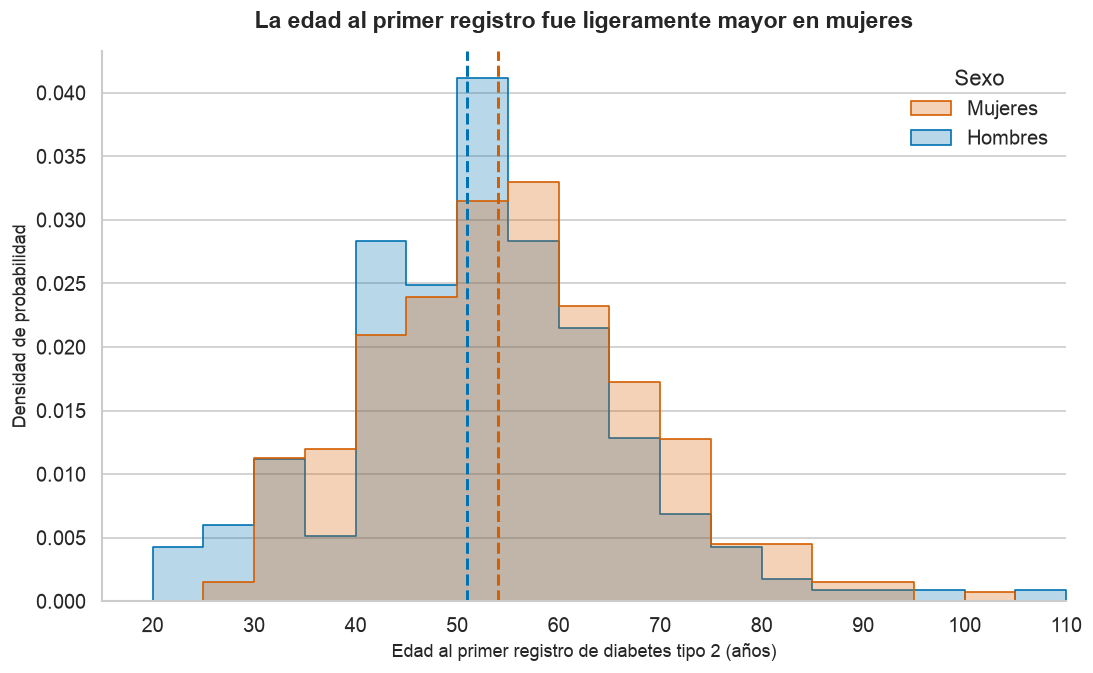

In [41]:
# Distribución de edad por sexo — Seaborn

fig_seaborn, ax = plt.subplots(
    figsize=(9, 5.5),
    layout="constrained",
)

sns.histplot(
    data=cohorte,
    x="edad_indice",
    hue="sexo",
    hue_order=["Mujeres", "Hombres"],
    palette=COLORES_SEXO,
    bins=intervalos_edad,
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.28,
    ax=ax,
)

for grupo in ["Mujeres", "Hombres"]:
    ax.axvline(
        resumen_figura_edad.loc[grupo, "mediana"],
        color=COLORES_SEXO[grupo],
        linestyle="--",
        linewidth=1.8,
    )

ax.set_title(
    "La edad al primer registro fue ligeramente mayor en mujeres",
    fontsize=14,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel(
    "Edad al primer registro de diabetes tipo 2 (años)"
)

ax.set_ylabel(
    "Densidad de probabilidad"
)

ax.set_xlim(15, 110)
ax.set_xticks(np.arange(20, 111, 10))

leyenda = ax.get_legend()

if leyenda is not None:
    leyenda.set_title("Sexo")

ax.grid(axis="x", visible=False)
sns.despine(ax=ax)

plt.show()

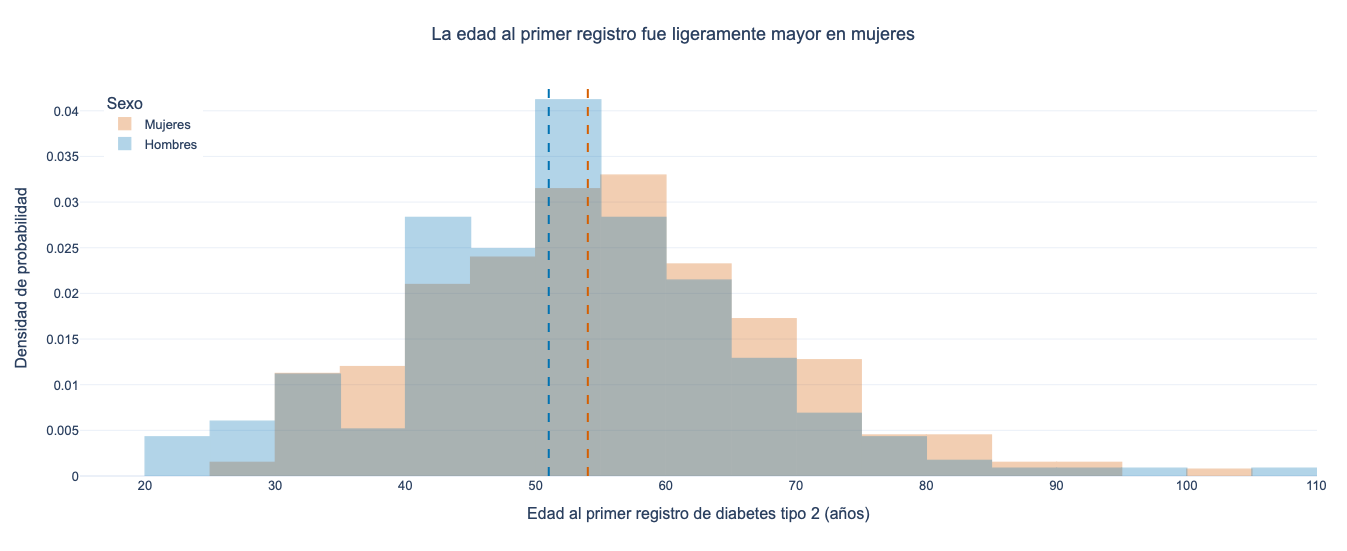

In [42]:
# Distribución de edad por sexo — Plotly

import plotly.graph_objects as go

fig_plotly = go.Figure()

fig_plotly.add_trace(
    go.Histogram(
        x=edades_mujeres,
        name="Mujeres",
        histnorm="probability density",
        xbins={
            "start": 15,
            "end": 110,
            "size": 5,
        },
        marker={
            "color": COLORES_SEXO["Mujeres"],
            "line": {
                "color": COLORES_SEXO["Mujeres"],
                "width": 1.3,
            },
        },
        opacity=0.30,
    )
)

fig_plotly.add_trace(
    go.Histogram(
        x=edades_hombres,
        name="Hombres",
        histnorm="probability density",
        xbins={
            "start": 15,
            "end": 110,
            "size": 5,
        },
        marker={
            "color": COLORES_SEXO["Hombres"],
            "line": {
                "color": COLORES_SEXO["Hombres"],
                "width": 1.3,
            },
        },
        opacity=0.30,
    )
)

fig_plotly.add_vline(
    x=float(np.median(edades_mujeres)),
    line_color=COLORES_SEXO["Mujeres"],
    line_dash="dash",
    line_width=2,
)

fig_plotly.add_vline(
    x=float(np.median(edades_hombres)),
    line_color=COLORES_SEXO["Hombres"],
    line_dash="dash",
    line_width=2,
)

fig_plotly.update_layout(
    title={
        "text": (
            "La edad al primer registro fue ligeramente "
            "mayor en mujeres"
        ),
        "x": 0.5,
        "xanchor": "center",
    },
    xaxis={
        "title": (
            "Edad al primer registro de diabetes tipo 2 (años)"
        ),
        "range": [15, 110],
        "tick0": 20,
        "dtick": 10,
        "showgrid": False,
    },
    yaxis={
        "title": "Densidad de probabilidad",
        "rangemode": "tozero",
    },
    barmode="overlay",
    template="plotly_white",
    width=900,
    height=550,
    legend={
        "title": {"text": "Sexo"},
        "x": 0.02,
        "y": 0.98,
    },
    font={
        "family": "Arial, sans-serif",
        "size": 13,
    },
    margin={
        "l": 80,
        "r": 30,
        "t": 80,
        "b": 75,
    },
)

fig_plotly.show()

### Comparación de las tres bibliotecas

| Biblioteca | Esfuerzo | Control | Resultado |
|---|---|---|---|
| Matplotlib | Requirió escribir cada elemento de forma explícita. | Ofreció el mayor control sobre ejes, barras, líneas y formato. | Figura estática precisa y adecuada para publicación. |
| Seaborn | Requirió menos código porque trabaja directamente con el DataFrame. | Permitió personalizar los elementos principales mediante Matplotlib. | Figura estática clara y rápida de construir. |
| Plotly | Requirió configurar trazas y diseño interactivo. | Facilitó explorar valores mediante zoom y herramientas emergentes. | Figura interactiva útil para exploración, aunque menos directa para una publicación estática. |

Seaborn resultó la opción más eficiente para el análisis exploratorio, mientras
que Matplotlib ofreció mayor control para la figura multipanel y la exportación
final. Plotly aportó interactividad, pero requirió una configuración diferente
para reproducir el mismo diseño.

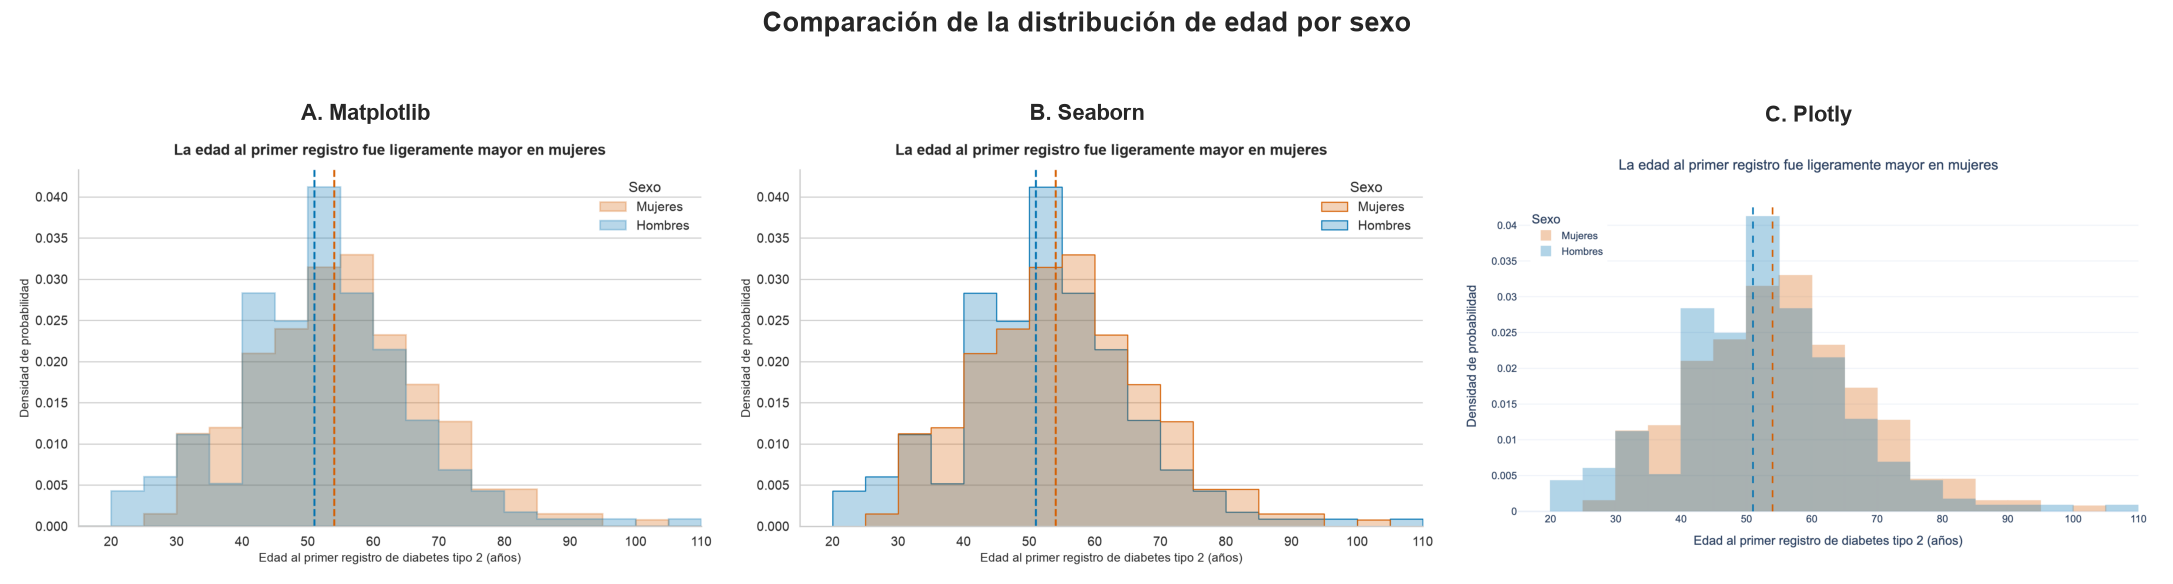

In [43]:
# Multipanel comparativo: Matplotlib, Seaborn y Plotly

from io import BytesIO
from PIL import Image


def figura_matplotlib_a_imagen(figura, dpi=180):
    """
    Convierte una figura de Matplotlib o Seaborn en una imagen
    sin crear archivos temporales.
    """
    buffer = BytesIO()

    figura.savefig(
        buffer,
        format="png",
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
    )

    buffer.seek(0)

    imagen = Image.open(buffer).convert("RGB")
    imagen.load()
    buffer.close()

    return imagen


def figura_plotly_a_imagen(figura, escala=2):
    """
    Convierte una figura de Plotly en una imagen mediante Kaleido.
    """
    contenido_png = figura.to_image(
        format="png",
        width=900,
        height=550,
        scale=escala,
    )

    buffer = BytesIO(contenido_png)
    imagen = Image.open(buffer).convert("RGB")
    imagen.load()
    buffer.close()

    return imagen


# Convertir las tres figuras ya creadas
imagen_matplotlib = figura_matplotlib_a_imagen(
    fig_matplotlib
)

imagen_seaborn = figura_matplotlib_a_imagen(
    fig_seaborn
)

imagen_plotly = figura_plotly_a_imagen(
    fig_plotly
)

# Construir la comparación
fig_comparacion, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5),
    layout="constrained",
)

imagenes = [
    imagen_matplotlib,
    imagen_seaborn,
    imagen_plotly,
]

titulos = [
    "A. Matplotlib",
    "B. Seaborn",
    "C. Plotly",
]

for ax, imagen, titulo in zip(
    axes,
    imagenes,
    titulos,
):
    ax.imshow(imagen)
    ax.set_title(
        titulo,
        fontsize=13,
        fontweight="bold",
        pad=10,
    )
    ax.axis("off")

fig_comparacion.suptitle(
    "Comparación de la distribución de edad por sexo",
    fontsize=16,
    fontweight="bold",
)

plt.show()

## 7. Tabla de características basales

#### Tabla 1. Características basales

La Tabla 1 resume las características de la cohorte completa y estratificadas
por sexo. Para cada paciente se seleccionó como HbA1c basal la medición
temporalmente más cercana a su fecha índice.

Las variables continuas se presentan como mediana e intervalo intercuartílico,
mientras que las variables categóricas se presentan como frecuencia y
porcentaje.

In [45]:
#Seleccionamos la HbA1c basal
# Distancia absoluta entre cada medición y la fecha índice
hba1c["distancia_indice_dias"] = (
    hba1c["dias_desde_indice"]
    .abs()
)

# Seleccionar la medición más cercana por paciente
hba1c_basal = (
    hba1c
    .sort_values(
        [
            "PATIENT",
            "distancia_indice_dias",
            "DATE",
        ]
    )
    .drop_duplicates(
        subset="PATIENT",
        keep="first",
    )
    [
        [
            "PATIENT",
            "DATE",
            "HbA1c",
            "dias_desde_indice",
            "distancia_indice_dias",
        ]
    ]
    .rename(
        columns={
            "PATIENT": "Id",
            "DATE": "fecha_hba1c_basal",
            "HbA1c": "hba1c_basal",
        }
    )
)

assert hba1c_basal["Id"].is_unique
assert len(hba1c_basal) == 500

hba1c_basal.head()

,Id,fecha_hba1c_basal,hba1c_basal,dias_desde_indice,distancia_indice_dias
2154,003bfc26-eb7d-8817-99a0-575e7765cf2c,2007-07-02 10:06:13,5.8,1813.0,1813.0
6097,0073373d-5b2f-00ab-de5e-0bcb674e1b32,2017-03-03 00:45:54,6.6,-35.0,35.0
3617,0085fb56-8743-5944-dea7-ae9e36e148cf,2022-10-14 15:44:58,7.5,-14.0,14.0
8961,014a9f96-b5b7-be37-e325-974c3f6851d7,2023-02-01 15:12:07,6.8,-21.0,21.0
8785,02334b70-a2e4-5262-4061-72e0f4820521,2016-10-15 19:31:17,2.6,4466.0,4466.0


In [46]:
#Incorporamos HbA1c a la cohorte
cohorte_tabla1 = cohorte.merge(
    hba1c_basal,
    on="Id",
    how="left",
    validate="one_to_one",
    indicator=True,
)

assert cohorte_tabla1["_merge"].eq("both").all()

cohorte_tabla1 = cohorte_tabla1.drop(
    columns="_merge"
)

print(
    "Pacientes en la Tabla 1:",
    f"{len(cohorte_tabla1):,}",
)

print(
    "HbA1c basal faltante:",
    cohorte_tabla1["hba1c_basal"].isna().sum(),
)

print("\nDistancia de la HbA1c a la fecha índice:")
print(
    cohorte_tabla1["distancia_indice_dias"]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

Pacientes en la Tabla 1: 500
HbA1c basal faltante: 0

Distancia de la HbA1c a la fecha índice:
count      500.000000
mean       473.581912
std       1771.075197
min          0.883472
25%         21.000000
50%         28.000000
75%         35.000000
90%        322.700000
95%       4364.150000
99%       8262.100000
max      16380.000000
Name: distancia_indice_dias, dtype: float64


In [47]:
#Revisamos categorías
for variable in [
    "sexo",
    "RACE",
    "ETHNICITY",
    "MARITAL",
]:
    print(f"\n{variable}")
    print(
        cohorte_tabla1[variable]
        .value_counts(
            dropna=False
        )
    )


sexo
sexo
Mujeres    267
Hombres    233
Name: count, dtype: int64

RACE
RACE
white       415
asian        35
black        34
other         9
hawaiian      5
native        2
Name: count, dtype: int64

ETHNICITY
ETHNICITY
nonhispanic    450
hispanic        50
Name: count, dtype: int64

MARITAL
MARITAL
M      286
S       91
D       86
W       32
NaN      5
Name: count, dtype: int64


**Nota:** Aunque todos los pacientes tenían alguna medición de HbA1c, en algunos casos
la medición más cercana estaba varios años alejada de la fecha índice. Para
evitar clasificar esas observaciones como basales, se consideró válida
únicamente una medición obtenida dentro de los 90 días anteriores o posteriores
al primer registro de diabetes.

In [48]:
VENTANA_HBA1C_BASAL_DIAS = 90

cohorte_tabla1["hba1c_basal_90d"] = (
    cohorte_tabla1["hba1c_basal"]
    .where(
        cohorte_tabla1["distancia_indice_dias"]
        <= VENTANA_HBA1C_BASAL_DIAS
    )
)

n_hba1c_disponible = (
    cohorte_tabla1["hba1c_basal_90d"]
    .notna()
    .sum()
)

print(
    "HbA1c basal disponible:",
    f"{n_hba1c_disponible:,} de {len(cohorte_tabla1):,}",
)

print(
    "Cobertura:",
    f"{n_hba1c_disponible / len(cohorte_tabla1) * 100:.1f}%",
)

print(
    "HbA1c basal faltante:",
    cohorte_tabla1["hba1c_basal_90d"].isna().sum(),
)

HbA1c basal disponible: 441 de 500
Cobertura: 88.2%
HbA1c basal faltante: 59


In [49]:
#Creamos indicadores de comorbilidad
# Seleccionar las cinco comorbilidades basales más frecuentes
top_5_tabla1 = (
    top_comorbilidades
    .head(5)
    [
        [
            "REASONCODE",
            "comorbilidad",
        ]
    ]
    .copy()
)

diagnosticos_unicos = (
    comorbilidades_basales[
        [
            "PATIENT",
            "REASONCODE",
        ]
    ]
    .drop_duplicates()
)

for _, fila in top_5_tabla1.iterrows():
    codigo = fila["REASONCODE"]
    nombre = fila["comorbilidad"]

    ids_con_diagnostico = set(
        diagnosticos_unicos.loc[
            diagnosticos_unicos["REASONCODE"] == codigo,
            "PATIENT",
        ]
    )

    cohorte_tabla1[f"comorb_{nombre}"] = (
        cohorte_tabla1["Id"]
        .isin(ids_con_diagnostico)
    )

top_5_tabla1

,REASONCODE,comorbilidad
0,66383009,Gingivitis
1,271737000,Anemia
2,82423001,Dolor crónico
3,414545008,Cardiopatía isquémica
4,609328004,Predisposición alérgica


In [52]:
# Función para la creación de la Tabla 1

def mediana_iqr(serie, decimales=1):
    valores = pd.to_numeric(
        serie,
        errors="coerce",
    ).dropna()

    if valores.empty:
        return "NA"

    mediana = valores.median()
    q1 = valores.quantile(0.25)
    q3 = valores.quantile(0.75)

    return (
        f"{mediana:.{decimales}f} "
        f"[{q1:.{decimales}f}–{q3:.{decimales}f}]"
    )


def frecuencia_porcentaje(mascara, denominador):
    n = int(mascara.fillna(False).sum())
    porcentaje = n / denominador * 100

    return f"{n} ({porcentaje:.1f}%)"


def agregar_fila(tabla, caracteristica, funcion):
    fila = {"Característica": caracteristica}

    for nombre_grupo, datos_grupo in grupos_tabla1.items():
        fila[nombre_grupo] = funcion(datos_grupo)

    tabla.append(fila)

# Definimos grupos

grupos_tabla1 = {
    "Total": cohorte_tabla1,
    "Mujeres": cohorte_tabla1.loc[
        cohorte_tabla1["sexo"] == "Mujeres"
    ],
    "Hombres": cohorte_tabla1.loc[
        cohorte_tabla1["sexo"] == "Hombres"
    ],
}

filas_tabla1 = []

# Tamaño de los grupos
agregar_fila(
    filas_tabla1,
    "Pacientes, n",
    lambda datos: f"{len(datos)}",
)

# Variables continuas
agregar_fila(
    filas_tabla1,
    "Edad al índice, años",
    lambda datos: mediana_iqr(
        datos["edad_indice"],
        decimales=1,
    ),
)

agregar_fila(
    filas_tabla1,
    "HbA1c basal, %",
    lambda datos: mediana_iqr(
        datos["hba1c_basal_90d"],
        decimales=1,
    ),
)

agregar_fila(
    filas_tabla1,
    "HbA1c disponible, n",
    lambda datos: (
        f"{datos['hba1c_basal_90d'].notna().sum()}"
    ),
)

agregar_fila(
    filas_tabla1,
    "Ingreso anual",
    lambda datos: mediana_iqr(
        datos["INCOME"],
        decimales=0,
    ),
)

# Raza
TRADUCCION_RAZA = {
    "white": "Blanca",
    "asian": "Asiática",
    "black": "Negra",
    "other": "Otra",
    "hawaiian": "Hawaiana/islas del Pacífico",
    "native": "Nativa",
}

for codigo, etiqueta in TRADUCCION_RAZA.items():
    agregar_fila(
        filas_tabla1,
        f"Raza: {etiqueta}, n (%)",
        lambda datos, valor=codigo: frecuencia_porcentaje(
            datos["RACE"].astype("string") == valor,
            len(datos),
        ),
    )

# Etnicidad
TRADUCCION_ETNICIDAD = {
    "hispanic": "Hispana",
    "nonhispanic": "No hispana",
}

for codigo, etiqueta in TRADUCCION_ETNICIDAD.items():
    agregar_fila(
        filas_tabla1,
        f"Etnicidad: {etiqueta}, n (%)",
        lambda datos, valor=codigo: frecuencia_porcentaje(
            datos["ETHNICITY"].astype("string") == valor,
            len(datos),
        ),
    )

# Estado civil
TRADUCCION_ESTADO_CIVIL = {
    "M": "Casado/a",
    "S": "Soltero/a",
    "D": "Divorciado/a",
    "W": "Viudo/a",
}

for codigo, etiqueta in TRADUCCION_ESTADO_CIVIL.items():
    agregar_fila(
        filas_tabla1,
        f"Estado civil: {etiqueta}, n (%)",
        lambda datos, valor=codigo: frecuencia_porcentaje(
            datos["MARITAL"].astype("string") == valor,
            len(datos),
        ),
    )

agregar_fila(
    filas_tabla1,
    "Estado civil: faltante, n (%)",
    lambda datos: frecuencia_porcentaje(
        datos["MARITAL"].isna(),
        len(datos),
    ),
)

# Comorbilidades
for nombre in top_5_tabla1["comorbilidad"]:
    columna = f"comorb_{nombre}"

    agregar_fila(
        filas_tabla1,
        f"{nombre}, n (%)",
        lambda datos, col=columna: frecuencia_porcentaje(
            datos[col],
            len(datos),
        ),
    )

tabla1 = pd.DataFrame(filas_tabla1)

tabla1

,Característica,Total,Mujeres,Hombres
0,"Pacientes, n",500,267,233
1,"Edad al índice, años",52.5 [44.8–61.0],54.0 [46.0–62.5],51.0 [44.0–60.0]
2,"HbA1c basal, %",7.1 [6.9–7.5],7.1 [6.9–7.5],7.1 [6.9–7.5]
3,"HbA1c disponible, n",441,236,205
4,Ingreso anual,72318 [32098–127294],74628 [32240–136802],69129 [31312–112972]
5,"Raza: Blanca, n (%)",415 (83.0%),228 (85.4%),187 (80.3%)
6,"Raza: Asiática, n (%)",35 (7.0%),15 (5.6%),20 (8.6%)
7,"Raza: Negra, n (%)",34 (6.8%),13 (4.9%),21 (9.0%)
8,"Raza: Otra, n (%)",9 (1.8%),6 (2.2%),3 (1.3%)
9,"Raza: Hawaiana/islas del Pacífico, n (%)",5 (1.0%),3 (1.1%),2 (0.9%)


In [51]:
#Guardamos la Tabla 1
RUTA_TABLA1 = (
    RESULTS_DIR
    / "tabla1_caracteristicas_basales.csv"
)

tabla1.to_csv(
    RUTA_TABLA1,
    index=False,
    encoding="utf-8-sig",
)

print(f"Tabla guardada en: {RUTA_TABLA1}")
print(f"Existe: {RUTA_TABLA1.exists()}")

Tabla guardada en: /Users/alejandrogarciacolorado/EE_CDB/lab03/tu-entrega/resultados/tabla1_caracteristicas_basales.csv
Existe: True


**Nota de la Tabla 1.** Las variables continuas se presentan como mediana [Q1–Q3] y las
categóricas como n (%). La HbA1c basal se definió como la medición más cercana
dentro de ±90 días de la fecha índice. Los porcentajes se calcularon utilizando
como denominador el total de pacientes de cada columna.

## 8.Exportar PDF vectorial y PNG a 300 dpi

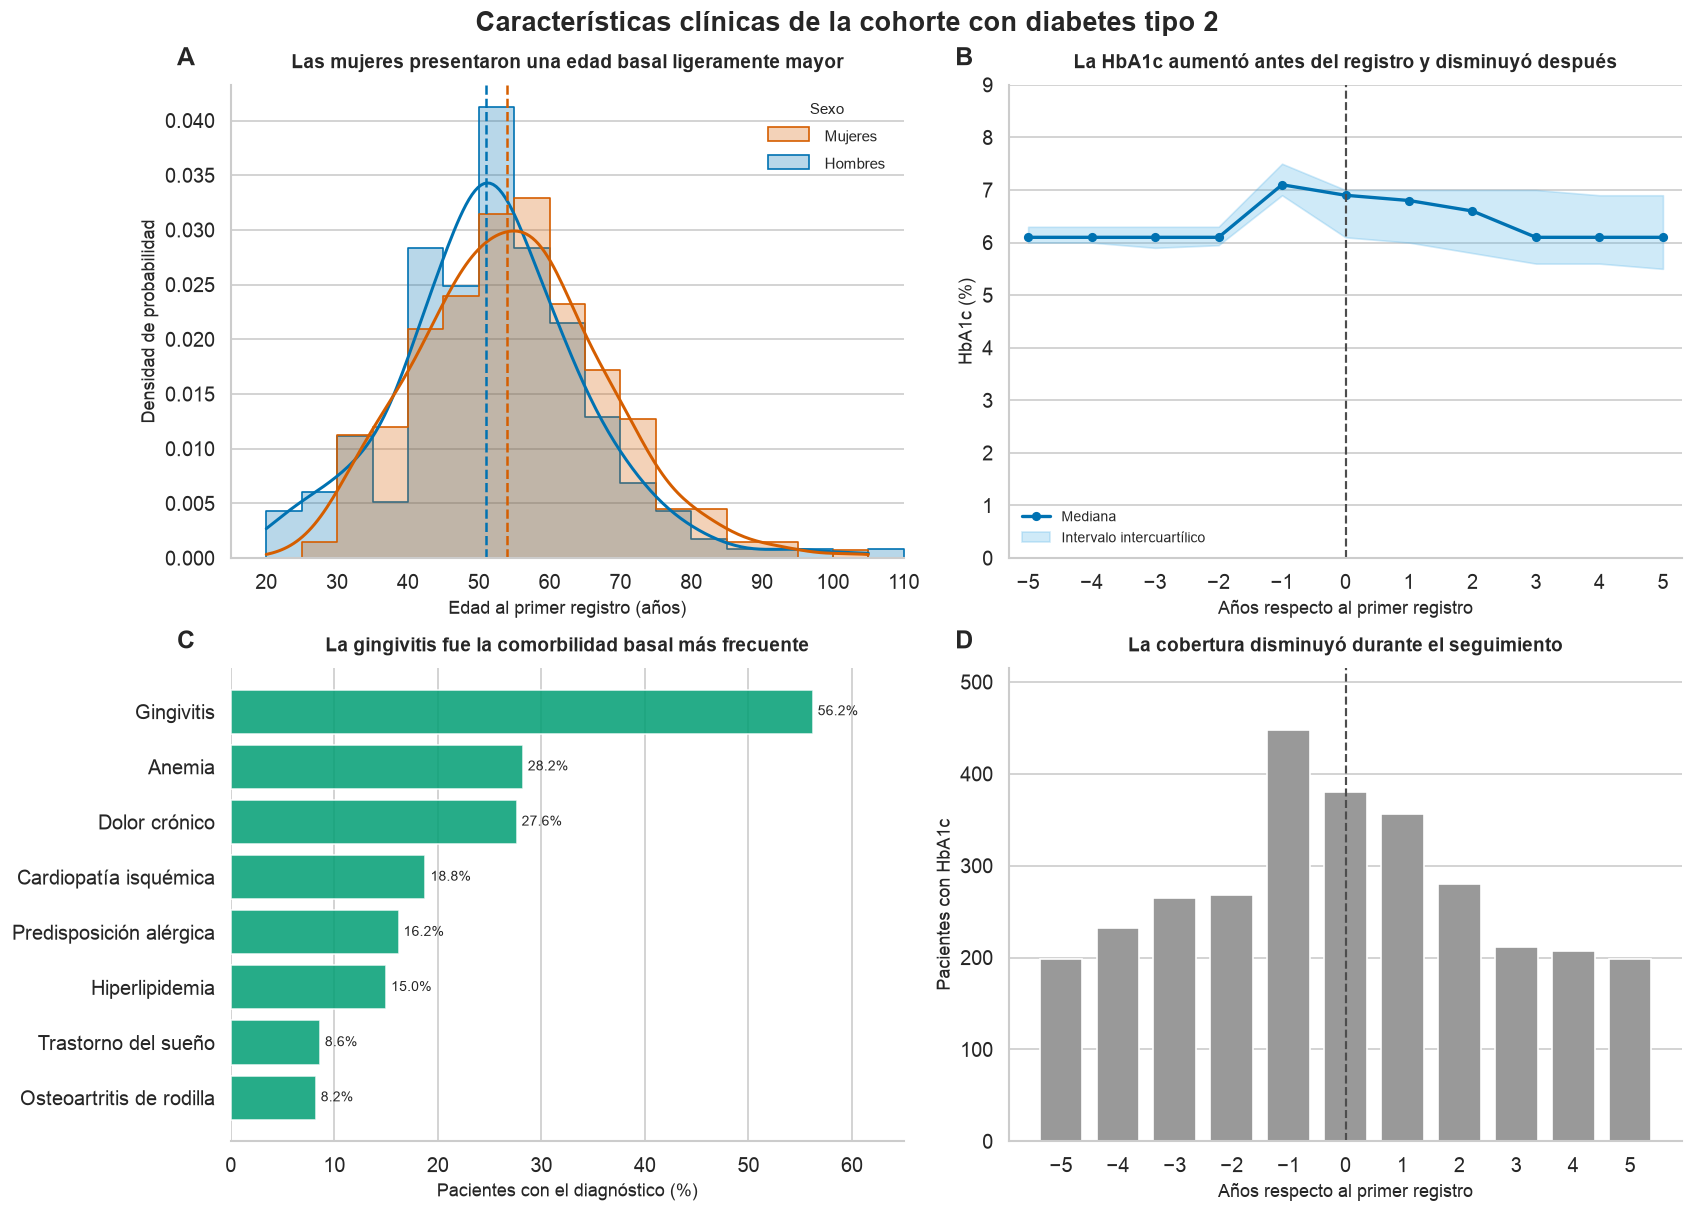

In [55]:
# Figura multipanel 2 × 2

fig_multipanel, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10),
    layout="constrained",
)

ax_a, ax_b = axes[0]
ax_c, ax_d = axes[1]

# Panel A — Distribución de edad

sns.histplot(
    data=cohorte,
    x="edad_indice",
    hue="sexo",
    hue_order=["Mujeres", "Hombres"],
    palette=COLORES_SEXO,
    bins=np.arange(15, 111, 5),
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.28,
    kde=True,
    kde_kws={
        "cut": 0,
        "bw_adjust": 1,
    },
    line_kws={
        "linewidth": 1.8,
    },
    ax=ax_a,
)

for grupo in ["Mujeres", "Hombres"]:
    mediana = resumen_figura_edad.loc[
        grupo,
        "mediana",
    ]

    ax_a.axvline(
        mediana,
        color=COLORES_SEXO[grupo],
        linestyle="--",
        linewidth=1.5,
    )

ax_a.set_title(
    "Las mujeres presentaron una edad basal ligeramente mayor",
    fontsize=11.5,
    fontweight="bold",
    pad=10,
)

ax_a.set_xlabel(
    "Edad al primer registro (años)"
)

ax_a.set_ylabel(
    "Densidad de probabilidad"
)

ax_a.set_xlim(15, 110)
ax_a.set_xticks(np.arange(20, 111, 10))

leyenda_a = ax_a.get_legend()

if leyenda_a is not None:
    leyenda_a.set_title("Sexo")
    leyenda_a.get_title().set_fontsize(9)

    for texto in leyenda_a.get_texts():
        texto.set_fontsize(9)

ax_a.grid(axis="x", visible=False)
sns.despine(ax=ax_a)

# Panel B — Evolución temporal de HbA1c

ax_b.plot(
    datos_temporales_multipanel["anio_relativo"],
    datos_temporales_multipanel["mediana_hba1c"],
    color="#0072B2",
    marker="o",
    markersize=4.5,
    linewidth=2,
    label="Mediana",
)

ax_b.fill_between(
    datos_temporales_multipanel["anio_relativo"].astype(float),
    datos_temporales_multipanel["q1_hba1c"].astype(float),
    datos_temporales_multipanel["q3_hba1c"].astype(float),
    color="#56B4E9",
    alpha=0.28,
    label="Intervalo intercuartílico",
)

ax_b.axvline(
    0,
    color="#4D4D4D",
    linestyle="--",
    linewidth=1.3,
)

ax_b.set_title(
    "La HbA1c aumentó antes del registro y disminuyó después",
    fontsize=11.5,
    fontweight="bold",
    pad=10,
)

ax_b.set_xlabel(
    "Años respecto al primer registro"
)

ax_b.set_ylabel(
    "HbA1c (%)"
)

ax_b.set_xlim(-5.3, 5.3)
ax_b.set_ylim(0, 9)
ax_b.set_xticks(np.arange(-5, 6, 1))

ax_b.legend(
    loc="lower left",
    fontsize=8.5,
    frameon=False,
)

ax_b.grid(axis="x", visible=False)
sns.despine(ax=ax_b)

# Panel C — Comorbilidades basales

barras_c = ax_c.barh(
    top_8_comorbilidades["comorbilidad"],
    top_8_comorbilidades["prevalencia_pct"],
    color="#009E73",
    alpha=0.85,
)

ax_c.bar_label(
    barras_c,
    labels=[
        f"{valor:.1f}%"
        for valor in top_8_comorbilidades["prevalencia_pct"]
    ],
    padding=3,
    fontsize=8.5,
)

ax_c.set_title(
    "La gingivitis fue la comorbilidad basal más frecuente",
    fontsize=11.5,
    fontweight="bold",
    pad=10,
)

ax_c.set_xlabel(
    "Pacientes con el diagnóstico (%)"
)

ax_c.set_ylabel("")

ax_c.set_xlim(
    0,
    max(
        65,
        top_8_comorbilidades["prevalencia_pct"].max() + 8,
    ),
)

ax_c.grid(axis="y", visible=False)
sns.despine(
    ax=ax_c,
    left=True,
)

# Panel D — Cobertura temporal

ax_d.bar(
    datos_temporales_multipanel["anio_relativo"],
    datos_temporales_multipanel["pacientes"],
    color="#999999",
    width=0.75,
)

ax_d.axvline(
    0,
    color="#4D4D4D",
    linestyle="--",
    linewidth=1.3,
)

ax_d.set_title(
    "La cobertura disminuyó durante el seguimiento",
    fontsize=11.5,
    fontweight="bold",
    pad=10,
)

ax_d.set_xlabel(
    "Años respecto al primer registro"
)

ax_d.set_ylabel(
    "Pacientes con HbA1c"
)

ax_d.set_xticks(np.arange(-5, 6, 1))

ax_d.set_ylim(
    0,
    datos_temporales_multipanel["pacientes"].max() * 1.15,
)

ax_d.grid(axis="x", visible=False)
sns.despine(ax=ax_d)

# Etiquetas de panel

for ax, etiqueta in zip(
    [ax_a, ax_b, ax_c, ax_d],
    ["A", "B", "C", "D"],
):
    ax.text(
        -0.08,
        1.08,
        etiqueta,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        ha="left",
        va="top",
    )

# Título general
fig_multipanel.suptitle(
    "Características clínicas de la cohorte con diabetes tipo 2",
    fontsize=16,
    fontweight="bold",
)

plt.show()

## Exportación de la figura final

La figura multipanel se exportó en PDF vectorial para conservar la calidad de
líneas, texto y formas, y en PNG con una resolución de 300 dpi para su
visualización e incorporación en documentos.

In [56]:
# Exportar figura final

RUTA_FIGURA_PDF = (
    FIGURES_DIR
    / "figura_multipanel_cohorte_diabetes.pdf"
)

RUTA_FIGURA_PNG = (
    FIGURES_DIR
    / "figura_multipanel_cohorte_diabetes.png"
)

# PDF vectorial
fig_multipanel.savefig(
    RUTA_FIGURA_PDF,
    format="pdf",
    bbox_inches="tight",
    facecolor="white",
    metadata={
        "Title": (
            "Características clínicas de la cohorte "
            "con diabetes tipo 2"
        ),
        "Author": "Alejandro García Colorado",
        "Subject": "Laboratorio 03 de análisis exploratorio",
    },
)

# PNG a 300 dpi
fig_multipanel.savefig(
    RUTA_FIGURA_PNG,
    format="png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

print(f"PDF guardado en:\n{RUTA_FIGURA_PDF}")
print(f"\nPNG guardado en:\n{RUTA_FIGURA_PNG}")

PDF guardado en:
/Users/alejandrogarciacolorado/EE_CDB/lab03/tu-entrega/figuras/figura_multipanel_cohorte_diabetes.pdf

PNG guardado en:
/Users/alejandrogarciacolorado/EE_CDB/lab03/tu-entrega/figuras/figura_multipanel_cohorte_diabetes.png


In [57]:
RUTA_COMPARACION_PNG = (
    FIGURES_DIR
    / "comparacion_matplotlib_seaborn_plotly.png"
)

fig_comparacion.savefig(
    RUTA_COMPARACION_PNG,
    format="png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

print(
    "Comparación guardada en:",
    RUTA_COMPARACION_PNG,
)

Comparación guardada en: /Users/alejandrogarciacolorado/EE_CDB/lab03/tu-entrega/figuras/comparacion_matplotlib_seaborn_plotly.png


In [58]:
RUTA_PLOTLY_HTML = (
    FIGURES_DIR
    / "distribucion_edad_plotly.html"
)

fig_plotly.write_html(
    RUTA_PLOTLY_HTML,
    include_plotlyjs="cdn",
    full_html=True,
)

print(
    "Figura interactiva guardada en:",
    RUTA_PLOTLY_HTML,
)

Figura interactiva guardada en: /Users/alejandrogarciacolorado/EE_CDB/lab03/tu-entrega/figuras/distribucion_edad_plotly.html


In [59]:
from PIL import Image

archivos_exportados = [
    RUTA_FIGURA_PDF,
    RUTA_FIGURA_PNG,
    RUTA_COMPARACION_PNG,
    RUTA_PLOTLY_HTML,
    RUTA_TABLA1,
]

for archivo in archivos_exportados:
    tamaño_kb = archivo.stat().st_size / 1024

    print(
        f"{archivo.name}: "
        f"existe = {archivo.exists()}, "
        f"tamaño = {tamaño_kb:,.1f} KB"
    )

with Image.open(RUTA_FIGURA_PNG) as imagen_png:
    print("\nDimensiones del PNG:", imagen_png.size)
    print("Resolución registrada:", imagen_png.info.get("dpi"))

figura_multipanel_cohorte_diabetes.pdf: existe = True, tamaño = 41.8 KB
figura_multipanel_cohorte_diabetes.png: existe = True, tamaño = 479.3 KB
comparacion_matplotlib_seaborn_plotly.png: existe = True, tamaño = 416.9 KB
distribucion_edad_plotly.html: existe = True, tamaño = 13.9 KB
tabla1_caracteristicas_basales.csv: existe = True, tamaño = 1.4 KB

Dimensiones del PNG: (4234, 3034)
Resolución registrada: (299.9994, 299.9994)


## Hallazgos principales

1. **Las mujeres presentaron una edad ligeramente mayor al primer registro de
   diabetes tipo 2.** La mediana fue de 54 años en mujeres y 51 años en
   hombres, aunque las distribuciones mostraron una superposición amplia.

2. **La HbA1c aumentó antes del primer registro y disminuyó durante el
   seguimiento.** La mediana alcanzó 7.1 % en el año previo al registro,
   descendió a 6.9 % durante el primer año y se mantuvo alrededor de 6.1 %
   entre los años tres y cinco. Este resultado es descriptivo y no demuestra
   que el descenso haya sido causado por un tratamiento.

3. **La gingivitis fue la comorbilidad basal registrada con mayor frecuencia.**
   Se identificó en 56.2 % de los pacientes, seguida por anemia (28.2 %),
   dolor crónico (27.6 %), cardiopatía isquémica (18.8 %) e hiperlipidemia
   (15.0 %).

## Limitaciones

La cohorte se definió mediante diagnósticos registrados como motivo de
encuentro, por lo que podría no incluir pacientes cuya diabetes no fuera el
motivo principal de una consulta. De manera similar, las comorbilidades
representan diagnósticos documentados en los encuentros y no una reconstrucción
completa de todas las enfermedades.

La cobertura disminuyó conforme aumentó el tiempo de seguimiento. Además, las
mediciones de HbA1c mostraron patrones repetitivos propios de datos simulados.
Por estas razones, los resultados deben interpretarse como un ejercicio
exploratorio sobre una población sintética y no como evidencia clínica
procedente de pacientes reales.

In [60]:
print("Resumen del Laboratorio 03")
print("-" * 40)
print(f"Pacientes de la cohorte: {len(cohorte):,}")
print(f"Mediciones de HbA1c: {len(hba1c):,}")
print(
    "Pacientes con HbA1c basal ±90 días:",
    f"{cohorte_tabla1['hba1c_basal_90d'].notna().sum():,}",
)
print(f"Comorbilidades graficadas: {len(top_8_comorbilidades)}")
print(f"Archivos exportados: {len(archivos_exportados)}")
print("\nLaboratorio completado correctamente.")

Resumen del Laboratorio 03
----------------------------------------
Pacientes de la cohorte: 500
Mediciones de HbA1c: 11,231
Pacientes con HbA1c basal ±90 días: 441
Comorbilidades graficadas: 8
Archivos exportados: 5

Laboratorio completado correctamente.
